In [ ]:
!apt install tesseract-ocr -y
!pip install pytesseract opencv-python pillow requests python-dotenv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
import pytesseract
from PIL import Image

def extract_text(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

result = extract_text("label.jpg")
print(result)

Nutrition Facts

1 servings per container
Serving size 4oz (100g)
OSC

 

Amount per serving
Calories 420

% Daily Value*

 

Total fat 21g
Saturated Fat 8g
Trans Fat Og

Cholesterol 50mg

Sodium 200mg

Total Carbohydrate 53g
Dietary Fiber less than 1g

Total Sugars 24g
Includes 23g Added Sugars 46%
Protein 5g

 

 

 

 

 

 

 

 

Vitamin D 0.1mcg
Calcium 27mg
Iron 1.8mg
Potassium 90mg

 

 

 

a
*The % Daily Value (DV) tells you how much a nutrient in
a serving of food contributes to a daily diet. 2,000 calories

day is used for general nutrition advice.

 



In [ ]:
import re

def parse_nutrition(text):
    data = {}

    cal_match = re.search(r'calories\s*(\d+)', text, re.IGNORECASE)
    if cal_match:
        data['calories'] = int(cal_match.group(1))

    fat_match = re.search(r'total fat\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if fat_match:
        data['total_fat_g'] = float(fat_match.group(1))

    sodium_match = re.search(r'sodium\s*(\d+\.?\d*)\s*mg', text, re.IGNORECASE)
    if sodium_match:
        data['sodium_mg'] = float(sodium_match.group(1))

    carb_match = re.search(r'total carboh[yi]d[nr]ate\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if carb_match:
        data['total_carbs_g'] = float(carb_match.group(1))

    serving_match = re.search(r'serving size\s*([^\n]+)', text, re.IGNORECASE)
    if serving_match:
        data['serving_size'] = serving_match.group(1).strip()

    return data

parsed = parse_nutrition(result)
print(parsed)

{'calories': 420, 'total_fat_g': 21.0, 'sodium_mg': 200.0, 'total_carbs_g': 53.0, 'serving_size': '4oz (100g)'}


In [ ]:
print(result)

Nutrition Facts

1 servings per container
Serving size 4oz (100g)
OSC

 

Amount per serving
Calories 420

% Daily Value*

 

Total fat 21g
Saturated Fat 8g
Trans Fat Og

Cholesterol 50mg

Sodium 200mg

Total Carbohydrate 53g
Dietary Fiber less than 1g

Total Sugars 24g
Includes 23g Added Sugars 46%
Protein 5g

 

 

 

 

 

 

 

 

Vitamin D 0.1mcg
Calcium 27mg
Iron 1.8mg
Potassium 90mg

 

 

 

a
*The % Daily Value (DV) tells you how much a nutrient in
a serving of food contributes to a daily diet. 2,000 calories

day is used for general nutrition advice.

 



In [ ]:
import re

def parse_nutrition(text):
    data = {}

    cal_match = re.search(r'calories\s*(\d+)', text, re.IGNORECASE)
    if cal_match:
        data['calories'] = int(cal_match.group(1))

    fat_match = re.search(r'total fat\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if fat_match:
        data['total_fat_g'] = float(fat_match.group(1))

    sat_fat_match = re.search(r'saturated fat\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if sat_fat_match:
        data['saturated_fat_g'] = float(sat_fat_match.group(1))

    cholesterol_match = re.search(r'cholesterol\s*(\d+\.?\d*)\s*mg', text, re.IGNORECASE)
    if cholesterol_match:
        data['cholesterol_mg'] = float(cholesterol_match.group(1))

    sodium_match = re.search(r'sodium\s*(\d+\.?\d*)\s*mg', text, re.IGNORECASE)
    if sodium_match:
        data['sodium_mg'] = float(sodium_match.group(1))

    carb_match = re.search(r'total carboh[yi]d[nr]ate\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if carb_match:
        data['total_carbs_g'] = float(carb_match.group(1))

    fiber_match = re.search(r'dietary fiber\s*(?:less than\s*)?(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if fiber_match:
        data['fiber_g'] = float(fiber_match.group(1))

    sugar_match = re.search(r'total sugars\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if sugar_match:
        data['total_sugars_g'] = float(sugar_match.group(1))

    added_sugar_match = re.search(r'includes\s*(\d+\.?\d*)\s*g added sugars', text, re.IGNORECASE)
    if added_sugar_match:
        data['added_sugars_g'] = float(added_sugar_match.group(1))

    protein_match = re.search(r'protein\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if protein_match:
        data['protein_g'] = float(protein_match.group(1))

    serving_match = re.search(r'serving size\s*([^\n]+)', text, re.IGNORECASE)
    if serving_match:
        data['serving_size'] = serving_match.group(1).strip()

    return data

parsed = parse_nutrition(result)
print(parsed)

{'calories': 420, 'total_fat_g': 21.0, 'saturated_fat_g': 8.0, 'cholesterol_mg': 50.0, 'sodium_mg': 200.0, 'total_carbs_g': 53.0, 'fiber_g': 1.0, 'total_sugars_g': 24.0, 'added_sugars_g': 23.0, 'protein_g': 5.0, 'serving_size': '4oz (100g)'}


In [ ]:
def generate_flags(data):
    flags = []

    # WHO: added sugar should be <10% of daily calories (~25g for 2000 cal diet)
    if data.get('added_sugars_g', 0) >= 20:
        flags.append(f"⚠️ HIGH ADDED SUGAR: {data['added_sugars_g']}g per serving (WHO daily limit ~25g)")

    # FDA: high sodium is 20%+ DV, which is ~460mg+ per serving
    if data.get('sodium_mg', 0) >= 400:
        flags.append(f"⚠️ HIGH SODIUM: {data['sodium_mg']}mg per serving")

    # High saturated fat: 5g+ per serving is considered high
    if data.get('saturated_fat_g', 0) >= 5:
        flags.append(f"⚠️ HIGH SATURATED FAT: {data['saturated_fat_g']}g per serving")

    # Low fiber despite high carbs
    if data.get('total_carbs_g', 0) >= 30 and data.get('fiber_g', 0) < 3:
        flags.append(f"⚠️ LOW FIBER relative to carbs: only {data['fiber_g']}g fiber")

    if not flags:
        flags.append("✅ No major health flags detected")

    return flags

flags = generate_flags(parsed)
for f in flags:
    print(f)

⚠️ HIGH ADDED SUGAR: 23.0g per serving (WHO daily limit ~25g)
⚠️ HIGH SATURATED FAT: 8.0g per serving
⚠️ LOW FIBER relative to carbs: only 1.0g fiber


In [ ]:
import requests

def search_openfoodfacts(query):
    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {
        "search_terms": query,
        "json": 1,
        "page_size": 5
    }
    headers = {
        "User-Agent": "FoodLabelReader/1.0 (internship project)"
    }
    response = requests.get(url, params=params, headers=headers)
    print(response.status_code)
    print(response.text[:200])
    return response.json()

result = search_openfoodfacts("nutella")
print(result['products'][0]['product_name'])

503
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Page temporarily unavailable - Open Food Facts


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
def search_openfoodfacts(query):
    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {
        "search_terms": query,
        "json": 1,
        "page_size": 5
    }
    headers = {
        "User-Agent": "FoodLabelReader/1.0 (internship project)"
    }
    response = requests.get(url, params=params, headers=headers)
    return response.json()

result = search_openfoodfacts("nutella")

product = result['products'][0]
print("Product Name:", product.get('product_name'))
print("Brand:", product.get('brands'))
print("Nutriments:", product.get('nutriments'))

In [ ]:
def get_clean_nutriments(product):
    nutriments = product.get('nutriments', {})
    return {
        'calories_100g': nutriments.get('energy-kcal_100g'),
        'fat_100g': nutriments.get('fat_100g'),
        'saturated_fat_100g': nutriments.get('saturated-fat_100g'),
        'carbs_100g': nutriments.get('carbohydrates_100g'),
        'sugars_100g': nutriments.get('sugars_100g'),
        'sodium_100g': nutriments.get('sodium_100g'),
        'protein_100g': nutriments.get('proteins_100g'),
    }

clean_data = get_clean_nutriments(product)
print(clean_data)

In [ ]:
def compare_with_database(ocr_data, db_data):
    comparison = {
        'ocr_sugar_g': ocr_data.get('total_sugars_g'),
        'db_sugar_per_100g': db_data.get('sugars_100g'),
        'ocr_sodium_mg': ocr_data.get('sodium_mg'),
        'db_sodium_per_100g': db_data.get('sodium_100g'),
    }
    return comparison

comparison = compare_with_database(parsed, clean_data)
print(comparison)

In [ ]:
DAILY_VALUES = {
    'calories': 2000,
    'total_fat_g': 78,
    'saturated_fat_g': 20,
    'cholesterol_mg': 300,
    'sodium_mg': 2300,
    'total_carbs_g': 275,
    'fiber_g': 28,
    'total_sugars_g': 50,
    'added_sugars_g': 50,
    'protein_g': 50,
}

def calculate_daily_value_percent(nutrient_data, daily_values=DAILY_VALUES):
    percentages = {}
    for nutrient, amount in nutrient_data.items():
        if nutrient in daily_values and amount is not None:
            pct = (amount / daily_values[nutrient]) * 100
            percentages[nutrient] = round(pct, 1)
    return percentages

dv_percent = calculate_daily_value_percent(parsed)
print(dv_percent)

In [ ]:
def generate_readable_insights(dv_percent, parsed_data):
    insights = []

    for nutrient, pct in dv_percent.items():
        nutrient_name = nutrient.replace('_g', '').replace('_mg', '').replace('_', ' ').title()

        if pct >= 40:
            insights.append(f"🔴 HIGH: {nutrient_name} — {pct}% of your daily value in one serving")
        elif pct >= 20:
            insights.append(f"🟡 MODERATE: {nutrient_name} — {pct}% of your daily value")
        elif pct <= 5:
            insights.append(f"🟢 LOW: {nutrient_name} — only {pct}% of your daily value")

    return insights

insights = generate_readable_insights(dv_percent, parsed)
for i in insights:
    print(i)

In [ ]:
# Sample ingredients text (jaise agar OCR se aata)
sample_ingredients_text = "Ingredients: Wheat flour, Sugar, Palm oil, Milk solids, Cocoa powder, Soy lecithin, Salt, Artificial flavor, Sodium benzoate"

def parse_ingredients(text):
    text = text.replace("Ingredients:", "").strip()
    ingredients = [item.strip() for item in text.split(",")]
    return ingredients

ingredients_list = parse_ingredients(sample_ingredients_text)
print(ingredients_list)

In [ ]:
ALLERGEN_KEYWORDS = {
    'Milk/Dairy': ['milk', 'dairy', 'lactose', 'casein', 'whey', 'butter', 'cream', 'cheese'],
    'Soy': ['soy', 'soya', 'soybean'],
    'Wheat/Gluten': ['wheat', 'gluten', 'barley', 'rye', 'flour'],
    'Nuts': ['almond', 'cashew', 'walnut', 'peanut', 'pistachio', 'hazelnut'],
    'Egg': ['egg', 'albumin'],
    'Sesame': ['sesame', 'tahini'],
}

def detect_allergens(ingredients_list):
    detected = {}
    for ingredient in ingredients_list:
        ingredient_lower = ingredient.lower()
        for allergen, keywords in ALLERGEN_KEYWORDS.items():
            for keyword in keywords:
                if keyword in ingredient_lower:
                    if allergen not in detected:
                        detected[allergen] = []
                    if ingredient not in detected[allergen]:   # duplicate check
                        detected[allergen].append(ingredient)
                    break   # ek keyword match hote hi next allergen pe jao
    return detected

allergens_found = detect_allergens(ingredients_list)
print(allergens_found)

In [ ]:
ADDITIVE_KEYWORDS = [
    'sodium benzoate', 'sodium nitrite', 'potassium sorbate', 'msg',
    'monosodium glutamate', 'artificial flavor', 'artificial color',
    'aspartame', 'high fructose corn syrup', 'bha', 'bht',
    'sodium bisulfite', 'tartrazine', 'red 40', 'yellow 5', 'blue 1'
]

def detect_additives(ingredients_list):
    found_additives = []
    for ingredient in ingredients_list:
        ingredient_lower = ingredient.lower()
        for additive in ADDITIVE_KEYWORDS:
            if additive in ingredient_lower:
                found_additives.append(ingredient)
                break
    return found_additives

additives_found = detect_additives(ingredients_list)
print(additives_found)

In [ ]:
def get_nutriscore(product):
    grade = product.get('nutriscore_grade', 'unknown')
    grade_meaning = {
        'a': 'Excellent nutritional quality',
        'b': 'Good nutritional quality',
        'c': 'Average nutritional quality',
        'd': 'Poor nutritional quality',
        'e': 'Bad nutritional quality',
        'unknown': 'No grade available'
    }
    return {
        'grade': grade.upper() if grade != 'unknown' else 'N/A',
        'meaning': grade_meaning.get(grade, 'Unknown')
    }

nutriscore = get_nutriscore(product)
print(nutriscore)

In [ ]:
def get_nova_group(product):
    nova = product.get('nova_group', None)
    nova_meaning = {
        1: 'Unprocessed or minimally processed food',
        2: 'Processed culinary ingredient',
        3: 'Processed food',
        4: 'Ultra-processed food'
    }
    return {
        'nova_group': nova,
        'meaning': nova_meaning.get(nova, 'Unknown')
    }

nova_info = get_nova_group(product)
print(nova_info)

In [ ]:
user_profile = {
    'is_diabetic': True,
    'is_hypertensive': False,
    'allergies': ['soy'],
    'goal': 'weight_loss'   # or 'muscle_gain', 'maintenance'
}

def personalized_flags(dv_percent, allergens_found, user_profile):
    flags = []

    if user_profile['is_diabetic'] and dv_percent.get('added_sugars_g', 0) >= 20:
        flags.append(f"🔴 DIABETIC ALERT: This has {dv_percent['added_sugars_g']}% of daily sugar limit — high risk for blood sugar spike")

    if user_profile['is_hypertensive'] and dv_percent.get('sodium_mg', 0) >= 20:
        flags.append(f"🔴 HYPERTENSION ALERT: {dv_percent['sodium_mg']}% of daily sodium limit")

    for allergy in user_profile['allergies']:
        for allergen_type in allergens_found:
            if allergy.lower() in allergen_type.lower():
                flags.append(f"🚨 ALLERGY WARNING: Contains {allergen_type} — {allergens_found[allergen_type]}")

    if user_profile['goal'] == 'weight_loss' and dv_percent.get('calories', 0) >= 25:
        flags.append(f"⚠️ WEIGHT LOSS NOTE: {dv_percent['calories']}% of daily calories in one serving")

    return flags

personal_flags = personalized_flags(dv_percent, allergens_found, user_profile)
for f in personal_flags:
    print(f)

In [ ]:
scan_history = []

def log_scan(product_name, parsed_data, dv_percent, timestamp=None):
    import datetime
    entry = {
        'product': product_name,
        'timestamp': str(datetime.datetime.now()) if not timestamp else timestamp,
        'nutrition': parsed_data,
        'daily_value_percent': dv_percent
    }
    scan_history.append(entry)
    return entry

log_scan("Test Product", parsed, dv_percent)
print(scan_history)

In [ ]:
def calculate_daily_totals(scan_history):
    totals = {}
    for scan in scan_history:
        for nutrient, value in scan['nutrition'].items():
            if isinstance(value, (int, float)):
                totals[nutrient] = totals.get(nutrient, 0) + value
    return totals

def compare_totals_to_daily_values(totals, daily_values=DAILY_VALUES):
    result = {}
    for nutrient, total in totals.items():
        if nutrient in daily_values:
            pct = round((total / daily_values[nutrient]) * 100, 1)
            result[nutrient] = f"{total} ({pct}% of daily limit)"
    return result

daily_totals = calculate_daily_totals(scan_history)
daily_summary = compare_totals_to_daily_values(daily_totals)
print(daily_summary)

In [ ]:
def generate_full_report(ocr_data, dv_percent, insights, allergens, additives, nutriscore, nova_info, personal_flags):
    print("=" * 50)
    print("FOOD LABEL ANALYSIS REPORT")
    print("=" * 50)
    print(f"\n📊 NUTRITION DATA: {ocr_data}")
    print(f"\n📈 % DAILY VALUE: {dv_percent}")
    print(f"\n💡 INSIGHTS:")
    for i in insights:
        print(f"  {i}")
    print(f"\n🏷️ NUTRI-SCORE: {nutriscore['grade']} — {nutriscore['meaning']}")
    print(f"\n🏭 PROCESSING LEVEL: {nova_info}")
    print(f"\n⚠️ ALLERGENS: {allergens if allergens else 'None detected'}")
    print(f"\n🧪 ADDITIVES: {additives if additives else 'None detected'}")
    print(f"\n👤 PERSONALIZED FLAGS:")
    for f in personal_flags:
        print(f"  {f}")
    print("=" * 50)

generate_full_report(parsed, dv_percent, insights, allergens_found, additives_found, nutriscore, nova_info, personal_flags)

In [ ]:
VEGAN_CONFLICT_KEYWORDS = ['milk', 'whey', 'casein', 'egg', 'honey', 'gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork']
VEGETARIAN_CONFLICT_KEYWORDS = ['gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork', 'rennet']

def check_diet_compatibility(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()

    vegan_conflicts = [kw for kw in VEGAN_CONFLICT_KEYWORDS if kw in ingredients_text]
    vegetarian_conflicts = [kw for kw in VEGETARIAN_CONFLICT_KEYWORDS if kw in ingredients_text]

    return {
        'vegan_friendly': len(vegan_conflicts) == 0,
        'vegan_conflicts': vegan_conflicts,
        'vegetarian_friendly': len(vegetarian_conflicts) == 0,
        'vegetarian_conflicts': vegetarian_conflicts
    }

diet_check = check_diet_compatibility(ingredients_list)
print(diet_check)

In [ ]:
def get_ecoscore(product):
    grade = product.get('ecoscore_grade', 'unknown')
    grade_meaning = {
        'a': 'Very low environmental impact',
        'b': 'Low environmental impact',
        'c': 'Moderate environmental impact',
        'd': 'High environmental impact',
        'e': 'Very high environmental impact',
        'unknown': 'No data available'
    }
    return {
        'grade': grade.upper() if grade != 'unknown' else 'N/A',
        'meaning': grade_meaning.get(grade, 'Unknown')
    }

ecoscore = get_ecoscore(product)
print(ecoscore)

In [ ]:
def estimate_glycemic_load_risk(parsed_data):
    carbs = parsed_data.get('total_carbs_g', 0)
    fiber = parsed_data.get('fiber_g', 0)
    sugar = parsed_data.get('total_sugars_g', 0)

    net_carbs = carbs - fiber

    if sugar >= 15 and fiber < 3:
        risk = "HIGH — likely to spike blood sugar quickly"
    elif sugar >= 8 or net_carbs >= 20:
        risk = "MODERATE"
    else:
        risk = "LOW"

    return {
        'net_carbs_g': round(net_carbs, 1),
        'blood_sugar_spike_risk': risk
    }

glycemic_info = estimate_glycemic_load_risk(parsed)
print(glycemic_info)

In [ ]:
ARTIFICIAL_SWEETENERS = ['aspartame', 'sucralose', 'saccharin', 'acesulfame', 'stevia', 'xylitol', 'sorbitol', 'erythritol']

def detect_sweeteners(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()
    found = [sw for sw in ARTIFICIAL_SWEETENERS if sw in ingredients_text]
    return found if found else "No artificial sweeteners detected"

sweeteners = detect_sweeteners(ingredients_list)
print(sweeteners)

In [ ]:
def find_healthier_alternative(category_query, current_nutriscore):
    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {
        "search_terms": category_query,
        "json": 1,
        "page_size": 20,
    }
    headers = {"User-Agent": "FoodLabelReader/1.0"}

    response = requests.get(url, params=params, headers=headers)

    if response.status_code != 200:
        return f"API error: status {response.status_code}"

    try:
        data = response.json()
    except:
        return "Could not parse response as JSON"

    grade_order = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
    current_rank = grade_order.get(current_nutriscore.lower(), 5)

    alternatives = []
    for p in data.get('products', []):
        grade = p.get('nutriscore_grade', '').lower()
        if grade and grade_order.get(grade, 5) < current_rank:
            alternatives.append({
                'name': p.get('product_name'),
                'grade': grade.upper()
            })

    return alternatives[:5] if alternatives else "No healthier alternative found"

alternatives = find_healthier_alternative("chocolate spread", nutriscore['grade'])
print(alternatives)

In [ ]:
def calculate_portion(parsed_data, num_servings):
    scaled = {}
    for key, value in parsed_data.items():
        if isinstance(value, (int, float)):
            scaled[key] = round(value * num_servings, 1)
        else:
            scaled[key] = value
    return scaled

portioned = calculate_portion(parsed, 2)
print(portioned)

In [ ]:
import json

def export_report(report_data, filename="scan_report.json"):
    with open(filename, "w") as f:
        json.dump(report_data, f, indent=2)
    print(f"Report saved as {filename}")

full_report_data = {
    'nutrition': parsed,
    'daily_value_percent': dv_percent,
    'nutriscore': nutriscore,
    'ecoscore': ecoscore,
    'allergens': allergens_found,
    'additives': additives_found,
    'diet_compatibility': diet_check,
    'glycemic_risk': glycemic_info,
    'sweeteners': sweeteners
}

export_report(full_report_data)

In [ ]:
def get_product_by_barcode(barcode):
    url = f"https://world.openfoodfacts.org/api/v2/product/{barcode}.json"
    headers = {"User-Agent": "FoodLabelReader/1.0"}
    response = requests.get(url, headers=headers)
    data = response.json()
    if data.get('status') == 1:
        return data['product']
    return None

In [ ]:
NON_HALAL_KOSHER_KEYWORDS = ['pork', 'lard', 'gelatin', 'alcohol', 'wine', 'rum', 'bacon', 'ham']

def check_halal_kosher(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in NON_HALAL_KOSHER_KEYWORDS if kw in ingredients_text]
    return {
        'halal_kosher_safe': len(conflicts) == 0,
        'conflicts': conflicts
    }

In [ ]:
def compare_two_products(product1_data, product2_data):
    comparison = {}
    for key in product1_data:
        if key in product2_data and isinstance(product1_data[key], (int, float)):
            comparison[key] = {
                'product_1': product1_data[key],
                'product_2': product2_data[key],
                'lower_is': 'product_1' if product1_data[key] < product2_data[key] else 'product_2'
            }
    return comparison

In [ ]:
import re

def extract_expiry_info(text):
    patterns = [
        r'(?:best before|exp(?:iry)?|use by)[:\s]*(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})',
        r'(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})'
    ]
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group(1)
    return "Not found"

In [ ]:
def estimate_moisture_content(parsed_data):
    # rough estimate: 100g - (fat+carbs+protein+fiber) ≈ water+other
    known = sum([
        parsed_data.get('total_fat_g', 0),
        parsed_data.get('total_carbs_g', 0),
        parsed_data.get('protein_g', 0)
    ])
    return round(100 - known, 1) if known < 100 else 0

In [ ]:
api_cache = {}

def search_openfoodfacts_cached(query):
    if query in api_cache:
        return api_cache[query]
    result = search_openfoodfacts(query)
    api_cache[query] = result
    return result

In [ ]:
print(ingredients_list)
print(parsed)

In [ ]:
NON_HALAL_KOSHER_KEYWORDS = ['pork', 'lard', 'gelatin', 'alcohol', 'wine', 'rum', 'bacon', 'ham']

def check_halal_kosher(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in NON_HALAL_KOSHER_KEYWORDS if kw in ingredients_text]
    return {
        'halal_kosher_safe': len(conflicts) == 0,
        'conflicts': conflicts
    }

result = check_halal_kosher(ingredients_list)
print("RESULT:", result)

In [ ]:
comparison_result = compare_two_products(parsed, clean_data)
print("RESULT:", comparison_result)

In [ ]:
moisture = estimate_moisture_content(parsed)
print("RESULT:", moisture)

In [ ]:
sample_text_with_date = "Best before: 12/05/2026"
expiry = extract_expiry_info(sample_text_with_date)
print("RESULT:", expiry)

In [ ]:
api_cache = {}

def search_openfoodfacts_cached(query):
    if query in api_cache:
        print("Using cached result")
        return api_cache[query]

    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {
        "search_terms": query,
        "json": 1,
        "page_size": 5
    }
    headers = {
        "User-Agent": "FoodLabelReader/1.0 (internship project)"
    }
    response = requests.get(url, params=params, headers=headers)

    if response.status_code != 200:
        return None

    try:
        result = response.json()
        api_cache[query] = result
        return result
    except:
        return None

cached_result = search_openfoodfacts_cached("nutella")
if cached_result:
    print("RESULT:", cached_result['products'][0]['product_name'])
else:
    print("Request failed, try again")

In [ ]:
url = "https://world.openfoodfacts.org/cgi/search.pl"
params = {
    "search_terms": "nutella",
    "json": 1,
    "page_size": 5
}
headers = {
    "User-Agent": "FoodLabelReader/1.0 (internship project)"
}
response = requests.get(url, params=params, headers=headers)
print("Status code:", response.status_code)
print("Response text:", response.text[:300])

In [ ]:
api_cache = {}

def search_openfoodfacts_cached(query):
    if query in api_cache:
        print("Using cached result")
        return api_cache[query]

    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {
        "search_terms": query,
        "json": 1,
        "page_size": 5
    }
    headers = {
        "User-Agent": "FoodLabelReader/1.0 (internship project)"
    }
    response = requests.get(url, params=params, headers=headers)

    print("DEBUG status:", response.status_code)   # debug line

    if response.status_code != 200:
        print("DEBUG: bad status code")
        return None

    try:
        result = response.json()
        api_cache[query] = result
        return result
    except Exception as e:
        print("DEBUG error:", e)   # actual error dikhayega
        return None

cached_result = search_openfoodfacts_cached("nutella")
if cached_result:
    print("RESULT:", cached_result['products'][0]['product_name'])
else:
    print("Request failed, try again")

In [ ]:
# ============================================
# FOOD LABEL READER - COMPLETE PIPELINE
# ============================================

import pytesseract
from PIL import Image
import cv2
import re
import requests
import json
import datetime

# -------------------- OCR --------------------
def extract_text(image_path):
    img = Image.open(image_path)
    return pytesseract.image_to_string(img)

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    contrast = clahe.apply(gray)
    _, thresh = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cv2.imwrite("preprocessed.jpg", thresh)
    return "preprocessed.jpg"

# -------------------- PARSING --------------------
def parse_nutrition(text):
    data = {}
    patterns = {
        'calories': r'calories\s*(\d+)',
        'total_fat_g': r'total fat\s*(\d+\.?\d*)\s*g',
        'saturated_fat_g': r'saturated fat\s*(\d+\.?\d*)\s*g',
        'cholesterol_mg': r'cholesterol\s*(\d+\.?\d*)\s*mg',
        'sodium_mg': r'sodium\s*(\d+\.?\d*)\s*mg',
        'total_carbs_g': r'total carboh[yi]d[nr]ate\s*(\d+\.?\d*)\s*g',
        'fiber_g': r'dietary fiber\s*(?:less than\s*)?(\d+\.?\d*)\s*g',
        'total_sugars_g': r'total sugars\s*(\d+\.?\d*)\s*g',
        'added_sugars_g': r'includes\s*(\d+\.?\d*)\s*g added sugars',
        'protein_g': r'protein\s*(\d+\.?\d*)\s*g',
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            value = match.group(1)
            data[key] = int(value) if key == 'calories' else float(value)

    serving_match = re.search(r'serving size\s*([^\n]+)', text, re.IGNORECASE)
    if serving_match:
        data['serving_size'] = serving_match.group(1).strip()
    return data

def parse_ingredients(text):
    text = text.replace("Ingredients:", "").strip()
    return [item.strip() for item in text.split(",")]

def extract_expiry_info(text):
    patterns = [
        r'(?:best before|exp(?:iry)?|use by)[:\s]*(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})',
        r'(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})'
    ]
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group(1)
    return "Not found"

# -------------------- RDA / DAILY VALUE --------------------
DAILY_VALUES = {
    'calories': 2000, 'total_fat_g': 78, 'saturated_fat_g': 20,
    'cholesterol_mg': 300, 'sodium_mg': 2300, 'total_carbs_g': 275,
    'fiber_g': 28, 'total_sugars_g': 50, 'added_sugars_g': 50, 'protein_g': 50,
}

def calculate_daily_value_percent(nutrient_data, daily_values=DAILY_VALUES):
    percentages = {}
    for nutrient, amount in nutrient_data.items():
        if nutrient in daily_values and amount is not None:
            percentages[nutrient] = round((amount / daily_values[nutrient]) * 100, 1)
    return percentages

def generate_readable_insights(dv_percent):
    insights = []
    for nutrient, pct in dv_percent.items():
        name = nutrient.replace('_g', '').replace('_mg', '').replace('_', ' ').title()
        if pct >= 40:
            insights.append(f"🔴 HIGH: {name} — {pct}% of daily value")
        elif pct >= 20:
            insights.append(f"🟡 MODERATE: {name} — {pct}% of daily value")
        elif pct <= 5:
            insights.append(f"🟢 LOW: {name} — only {pct}% of daily value")
    return insights

def estimate_glycemic_load_risk(parsed_data):
    carbs = parsed_data.get('total_carbs_g', 0)
    fiber = parsed_data.get('fiber_g', 0)
    sugar = parsed_data.get('total_sugars_g', 0)
    net_carbs = carbs - fiber
    if sugar >= 15 and fiber < 3:
        risk = "HIGH — likely to spike blood sugar quickly"
    elif sugar >= 8 or net_carbs >= 20:
        risk = "MODERATE"
    else:
        risk = "LOW"
    return {'net_carbs_g': round(net_carbs, 1), 'blood_sugar_spike_risk': risk}

def estimate_moisture_content(parsed_data):
    known = sum([parsed_data.get('total_fat_g', 0), parsed_data.get('total_carbs_g', 0), parsed_data.get('protein_g', 0)])
    return round(100 - known, 1) if known < 100 else 0

def calculate_portion(parsed_data, num_servings):
    scaled = {}
    for key, value in parsed_data.items():
        scaled[key] = round(value * num_servings, 1) if isinstance(value, (int, float)) else value
    return scaled

# -------------------- ALLERGENS / ADDITIVES / DIET --------------------
ALLERGEN_KEYWORDS = {
    'Milk/Dairy': ['milk', 'dairy', 'lactose', 'casein', 'whey', 'butter', 'cream', 'cheese'],
    'Soy': ['soy', 'soya', 'soybean'],
    'Wheat/Gluten': ['wheat', 'gluten', 'barley', 'rye', 'flour'],
    'Nuts': ['almond', 'cashew', 'walnut', 'peanut', 'pistachio', 'hazelnut'],
    'Egg': ['egg', 'albumin'],
    'Sesame': ['sesame', 'tahini'],
}

def detect_allergens(ingredients_list):
    detected = {}
    for ingredient in ingredients_list:
        ing_lower = ingredient.lower()
        for allergen, keywords in ALLERGEN_KEYWORDS.items():
            for keyword in keywords:
                if keyword in ing_lower:
                    detected.setdefault(allergen, [])
                    if ingredient not in detected[allergen]:
                        detected[allergen].append(ingredient)
                    break
    return detected

ADDITIVE_KEYWORDS = ['sodium benzoate', 'sodium nitrite', 'potassium sorbate', 'msg', 'monosodium glutamate',
    'artificial flavor', 'artificial color', 'aspartame', 'high fructose corn syrup', 'bha', 'bht',
    'sodium bisulfite', 'tartrazine', 'red 40', 'yellow 5', 'blue 1']

def detect_additives(ingredients_list):
    found = []
    for ingredient in ingredients_list:
        ing_lower = ingredient.lower()
        for additive in ADDITIVE_KEYWORDS:
            if additive in ing_lower:
                found.append(ingredient)
                break
    return found

ARTIFICIAL_SWEETENERS = ['aspartame', 'sucralose', 'saccharin', 'acesulfame', 'stevia', 'xylitol', 'sorbitol', 'erythritol']

def detect_sweeteners(ingredients_list):
    text = " ".join(ingredients_list).lower()
    found = [sw for sw in ARTIFICIAL_SWEETENERS if sw in text]
    return found if found else "No artificial sweeteners detected"

VEGAN_CONFLICT_KEYWORDS = ['milk', 'whey', 'casein', 'egg', 'honey', 'gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork']
VEGETARIAN_CONFLICT_KEYWORDS = ['gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork', 'rennet']

def check_diet_compatibility(ingredients_list):
    text = " ".join(ingredients_list).lower()
    vegan_conflicts = [kw for kw in VEGAN_CONFLICT_KEYWORDS if kw in text]
    veg_conflicts = [kw for kw in VEGETARIAN_CONFLICT_KEYWORDS if kw in text]
    return {
        'vegan_friendly': len(vegan_conflicts) == 0, 'vegan_conflicts': vegan_conflicts,
        'vegetarian_friendly': len(veg_conflicts) == 0, 'vegetarian_conflicts': veg_conflicts
    }

NON_HALAL_KOSHER_KEYWORDS = ['pork', 'lard', 'gelatin', 'alcohol', 'wine', 'rum', 'bacon', 'ham']

def check_halal_kosher(ingredients_list):
    text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in NON_HALAL_KOSHER_KEYWORDS if kw in text]
    return {'halal_kosher_safe': len(conflicts) == 0, 'conflicts': conflicts}

# -------------------- OPENFOODFACTS API --------------------
api_cache = {}

def search_openfoodfacts(query):
    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {"search_terms": query, "json": 1, "page_size": 5}
    headers = {"User-Agent": "FoodLabelReader/1.0"}
    response = requests.get(url, params=params, headers=headers)
    if response.status_code != 200:
        return None
    try:
        return response.json()
    except:
        return None

def search_openfoodfacts_cached(query):
    if query in api_cache:
        return api_cache[query]
    result = search_openfoodfacts(query)
    if result:
        api_cache[query] = result
    return result

def get_product_by_barcode(barcode):
    url = f"https://world.openfoodfacts.org/api/v2/product/{barcode}.json"
    headers = {"User-Agent": "FoodLabelReader/1.0"}
    response = requests.get(url, headers=headers)
    try:
        data = response.json()
        return data['product'] if data.get('status') == 1 else None
    except:
        return None

def get_clean_nutriments(product):
    n = product.get('nutriments', {})
    return {
        'calories_100g': n.get('energy-kcal_100g'), 'fat_100g': n.get('fat_100g'),
        'saturated_fat_100g': n.get('saturated-fat_100g'), 'carbs_100g': n.get('carbohydrates_100g'),
        'sugars_100g': n.get('sugars_100g'), 'sodium_100g': n.get('sodium_100g'), 'protein_100g': n.get('proteins_100g'),
    }

def get_nutriscore(product):
    grade = product.get('nutriscore_grade', 'unknown')
    meanings = {'a': 'Excellent', 'b': 'Good', 'c': 'Average', 'd': 'Poor', 'e': 'Bad', 'unknown': 'N/A'}
    return {'grade': grade.upper() if grade != 'unknown' else 'N/A', 'meaning': meanings.get(grade, 'Unknown')}

def get_ecoscore(product):
    grade = product.get('ecoscore_grade', 'unknown')
    meanings = {'a': 'Very low impact', 'b': 'Low impact', 'c': 'Moderate impact', 'd': 'High impact', 'e': 'Very high impact', 'unknown': 'N/A'}
    return {'grade': grade.upper() if grade != 'unknown' else 'N/A', 'meaning': meanings.get(grade, 'Unknown')}

def get_nova_group(product):
    nova = product.get('nova_group', None)
    meanings = {1: 'Unprocessed/minimally processed', 2: 'Processed culinary ingredient', 3: 'Processed food', 4: 'Ultra-processed food'}
    return {'nova_group': nova, 'meaning': meanings.get(nova, 'Unknown')}

def find_healthier_alternative(category_query, current_nutriscore):
    result = search_openfoodfacts(category_query)
    if not result:
        return "API error"
    grade_order = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
    current_rank = grade_order.get(current_nutriscore.lower(), 5)
    alternatives = []
    for p in result.get('products', []):
        grade = p.get('nutriscore_grade', '').lower()
        if grade and grade_order.get(grade, 5) < current_rank:
            alternatives.append({'name': p.get('product_name'), 'grade': grade.upper()})
    return alternatives[:5] if alternatives else "No healthier alternative found"

# -------------------- PERSONALIZATION --------------------
def personalized_flags(dv_percent, allergens_found, user_profile):
    flags = []
    if user_profile['is_diabetic'] and dv_percent.get('added_sugars_g', 0) >= 20:
        flags.append(f"🔴 DIABETIC ALERT: {dv_percent['added_sugars_g']}% of daily sugar limit")
    if user_profile['is_hypertensive'] and dv_percent.get('sodium_mg', 0) >= 20:
        flags.append(f"🔴 HYPERTENSION ALERT: {dv_percent['sodium_mg']}% of daily sodium limit")
    for allergy in user_profile['allergies']:
        for allergen_type in allergens_found:
            if allergy.lower() in allergen_type.lower():
                flags.append(f"🚨 ALLERGY WARNING: Contains {allergen_type} — {allergens_found[allergen_type]}")
    if user_profile['goal'] == 'weight_loss' and dv_percent.get('calories', 0) >= 25:
        flags.append(f"⚠️ WEIGHT LOSS NOTE: {dv_percent['calories']}% of daily calories")
    return flags

# -------------------- HISTORY & EXPORT --------------------
scan_history = []

def log_scan(product_name, parsed_data, dv_percent):
    entry = {'product': product_name, 'timestamp': str(datetime.datetime.now()),
              'nutrition': parsed_data, 'daily_value_percent': dv_percent}
    scan_history.append(entry)
    return entry

def calculate_daily_totals(history):
    totals = {}
    for scan in history:
        for nutrient, value in scan['nutrition'].items():
            if isinstance(value, (int, float)):
                totals[nutrient] = totals.get(nutrient, 0) + value
    return totals

def export_report(report_data, filename="scan_report.json"):
    with open(filename, "w") as f:
        json.dump(report_data, f, indent=2)
    print(f"Saved as {filename}")

print("✅ All functions loaded successfully!")

In [ ]:
# Test the full pipeline
text = extract_text("label.jpg")
parsed = parse_nutrition(text)
dv_percent = calculate_daily_value_percent(parsed)
insights = generate_readable_insights(dv_percent)

for i in insights:
    print(i)

In [ ]:
# ============================================
# RUN FULL PIPELINE END-TO-END
# ============================================

# Step 1: OCR
text = extract_text("label.jpg")
ingredients_text = "Ingredients: Wheat flour, Sugar, Palm oil, Milk solids, Cocoa powder, Soy lecithin, Salt, Artificial flavor, Sodium benzoate"

# Step 2: Parse
parsed = parse_nutrition(text)
ingredients_list = parse_ingredients(ingredients_text)

# Step 3: RDA analysis
dv_percent = calculate_daily_value_percent(parsed)
insights = generate_readable_insights(dv_percent)
glycemic_info = estimate_glycemic_load_risk(parsed)
moisture = estimate_moisture_content(parsed)

# Step 4: Database lookup
product_data = search_openfoodfacts_cached("nutella")
product = product_data['products'][0]
nutriscore = get_nutriscore(product)
ecoscore = get_ecoscore(product)
nova_info = get_nova_group(product)

# Step 5: Ingredient intelligence
allergens_found = detect_allergens(ingredients_list)
additives_found = detect_additives(ingredients_list)
sweeteners = detect_sweeteners(ingredients_list)
diet_check = check_diet_compatibility(ingredients_list)
halal_kosher = check_halal_kosher(ingredients_list)

# Step 6: Personalization
user_profile = {'is_diabetic': True, 'is_hypertensive': False, 'allergies': ['soy'], 'goal': 'weight_loss'}
personal_flags = personalized_flags(dv_percent, allergens_found, user_profile)

# Step 7: History
log_scan("Test Product", parsed, dv_percent)

# ============================================
# FINAL REPORT
# ============================================
print("=" * 55)
print("FOOD LABEL ANALYSIS REPORT")
print("=" * 55)

print(f"\n📦 SERVING SIZE: {parsed.get('serving_size')}")

print(f"\n📊 NUTRITION DATA:")
for k, v in parsed.items():
    if k != 'serving_size':
        print(f"  {k}: {v}")

print(f"\n📈 % DAILY VALUE:")
for k, v in dv_percent.items():
    print(f"  {k}: {v}%")

print(f"\n💡 HEALTH INSIGHTS:")
for i in insights:
    print(f"  {i}")

print(f"\n🍬 GLYCEMIC RISK: {glycemic_info}")
print(f"\n💧 ESTIMATED MOISTURE: {moisture}g per 100g")

print(f"\n🏷️ NUTRI-SCORE: {nutriscore['grade']} — {nutriscore['meaning']}")
print(f"🌍 ECO-SCORE: {ecoscore['grade']} — {ecoscore['meaning']}")
print(f"🏭 PROCESSING LEVEL: {nova_info}")

print(f"\n🥗 INGREDIENTS: {ingredients_list}")
print(f"\n⚠️ ALLERGENS: {allergens_found if allergens_found else 'None detected'}")
print(f"🧪 ADDITIVES: {additives_found if additives_found else 'None detected'}")
print(f"🍯 SWEETENERS: {sweeteners}")
print(f"🌱 VEGAN FRIENDLY: {diet_check['vegan_friendly']} (conflicts: {diet_check['vegan_conflicts']})")
print(f"🥬 VEGETARIAN FRIENDLY: {diet_check['vegetarian_friendly']}")
print(f"☪️ HALAL/KOSHER SAFE: {halal_kosher['halal_kosher_safe']}")

print(f"\n👤 PERSONALIZED FLAGS (user profile: diabetic, soy allergy, weight loss goal):")
for f in personal_flags:
    print(f"  {f}")

print(f"\n📜 SCAN HISTORY: {len(scan_history)} scan(s) logged")

print("=" * 55)

In [ ]:
processed_path = preprocess_image("label.jpg")
text_from_processed = extract_text(processed_path)
print(text_from_processed)

In [ ]:
daily_totals = calculate_daily_totals(scan_history)
print("RESULT:", daily_totals)

In [ ]:
full_report_data = {
    'nutrition': parsed, 'daily_value_percent': dv_percent, 'nutriscore': nutriscore,
    'ecoscore': ecoscore, 'allergens': allergens_found, 'additives': additives_found,
    'diet_compatibility': diet_check, 'glycemic_risk': glycemic_info, 'sweeteners': sweeteners
}
export_report(full_report_data)

# Confirm the file actually exists
import os
print("File exists:", os.path.exists("scan_report.json"))

In [ ]:
barcode_test = get_product_by_barcode("YOUR_BARCODE_NUMBER_HERE")
print(barcode_test)

In [ ]:
print("scan_history:", scan_history)
print("length:", len(scan_history))

In [ ]:
daily_totals = calculate_daily_totals(scan_history)
print("RESULT:", daily_totals)

In [ ]:
def parse_vitamins_minerals(text):
    data = {}
    patterns = {
        'vitamin_d_mcg': r'vitamin d\s*(\d+\.?\d*)\s*mcg',
        'calcium_mg': r'calcium\s*(\d+\.?\d*)\s*mg',
        'iron_mg': r'iron\s*(\d+\.?\d*)\s*mg',
        'potassium_mg': r'potassium\s*(\d+\.?\d*)\s*mg',
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            data[key] = float(match.group(1))
    return data

vitamins = parse_vitamins_minerals(text)
print("RESULT:", vitamins)

In [ ]:
VITAMIN_DAILY_VALUES = {
    'vitamin_d_mcg': 20, 'calcium_mg': 1300, 'iron_mg': 18, 'potassium_mg': 4700
}

def calculate_vitamin_dv_percent(vitamin_data):
    percentages = {}
    for nutrient, amount in vitamin_data.items():
        if nutrient in VITAMIN_DAILY_VALUES:
            percentages[nutrient] = round((amount / VITAMIN_DAILY_VALUES[nutrient]) * 100, 1)
    return percentages

vitamin_dv = calculate_vitamin_dv_percent(vitamins)
print("RESULT:", vitamin_dv)

In [ ]:
def safe_extract_text(image_path):
    try:
        img = Image.open(image_path)
        text = pytesseract.image_to_string(img)
        if not text.strip():
            return None, "No text detected — image may be too blurry or dark"
        return text, None
    except FileNotFoundError:
        return None, f"Image not found: {image_path}"
    except Exception as e:
        return None, f"OCR failed: {str(e)}"

def safe_parse_nutrition(text):
    if not text:
        return {}
    return parse_nutrition(text)

# test with a bad path to confirm error handling works
test_text, error = safe_extract_text("nonexistent.jpg")
print("RESULT:", test_text, "| ERROR:", error)

# test with your real image
test_text2, error2 = safe_extract_text("label.jpg")
print("RESULT:", "Success" if test_text2 else error2)

In [ ]:
def convert_to_grams(value, unit):
    unit = unit.lower()
    conversions = {'g': 1, 'kg': 1000, 'mg': 0.001, 'oz': 28.35, 'lb': 453.6}
    return round(value * conversions.get(unit, 1), 2)

# test
converted = convert_to_grams(4, 'oz')
print("RESULT:", converted, "grams")

In [ ]:
import glob

def batch_process_images(folder_path="*.jpg"):
    results = []
    image_files = glob.glob(folder_path)
    for img_path in image_files:
        text, error = safe_extract_text(img_path)
        if text:
            parsed_data = parse_nutrition(text)
            results.append({'image': img_path, 'data': parsed_data})
        else:
            results.append({'image': img_path, 'error': error})
    return results

batch_results = batch_process_images("*.jpg")
print("RESULT:", batch_results)

In [ ]:
def run_tests():
    tests_passed = 0
    tests_failed = 0

    # Test 1: empty ingredients list
    result = detect_allergens([])
    assert result == {}, "Empty ingredients should return empty dict"
    tests_passed += 1

    # Test 2: missing calories field
    result = calculate_daily_value_percent({})
    assert result == {}, "Empty nutrition data should return empty dict"
    tests_passed += 1

    # Test 3: known allergen detected
    result = detect_allergens(["Milk powder"])
    assert 'Milk/Dairy' in result, "Should detect milk allergen"
    tests_passed += 1

    # Test 4: vegan conflict detection
    result = check_diet_compatibility(["Honey", "Water"])
    assert result['vegan_friendly'] == False, "Honey should trigger vegan conflict"
    tests_passed += 1

    print(f"RESULT: {tests_passed} tests passed, {tests_failed} tests failed")

run_tests()

In [ ]:
!pip install pyzbar reportlab langdetect -q
!apt-get install -y libzbar0 -q
import cv2, numpy as np, sqlite3, time, json, datetime
import matplotlib.pyplot as plt

In [ ]:
def check_image_quality(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return {'ok': False, 'reason': 'Could not read image'}

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()

    issues = []
    if blur_score < 100:
        issues.append(f'Image looks blurry (sharpness score: {blur_score:.1f}, want > 100)')
    if brightness < 60:
        issues.append(f'Image looks too dark (brightness: {brightness:.1f}/255)')
    elif brightness > 220:
        issues.append(f'Image looks overexposed/glare (brightness: {brightness:.1f}/255)')

    return {'ok': len(issues) == 0, 'issues': issues, 'blur_score': round(blur_score, 1), 'brightness': round(brightness, 1)}

quality = check_image_quality("label.jpg")
print("RESULT:", quality)

In [ ]:
def deskew_image(image_path, output_path="deskewed.jpg"):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

    coords = np.column_stack(np.where(thresh > 0))
    if len(coords) == 0:
        return image_path  # nothing to deskew

    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle

    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    cv2.imwrite(output_path, rotated)
    return output_path

deskewed_path = deskew_image("label.jpg")
print("RESULT: saved to", deskewed_path)

In [ ]:
!pip install pytesseract opencv-python pillow -q
!apt-get install -y tesseract-ocr -q

In [ ]:
from PIL import Image
import pytesseract

In [ ]:
def extract_text_with_confidence(image_path):
    img = Image.open(image_path)
    data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)

    confidences = [int(c) for c in data['conf'] if c != '-1' and int(c) >= 0]
    avg_confidence = round(sum(confidences) / len(confidences), 1) if confidences else 0
    low_conf_words = [data['text'][i] for i, c in enumerate(data['conf'])
                       if c != '-1' and 0 <= int(c) < 50 and data['text'][i].strip()]

    text = pytesseract.image_to_string(img)
    return {
        'text': text,
        'avg_confidence': avg_confidence,
        'reliable': avg_confidence >= 60,
        'low_confidence_words': low_conf_words
    }

ocr_result = extract_text_with_confidence("label.jpg")
print("RESULT: avg_confidence =", ocr_result['avg_confidence'], "| reliable =", ocr_result['reliable'])
print("Low-confidence words:", ocr_result['low_confidence_words'])

In [21]:
!apt-get update -qq
!apt-get install -y libzbar0 -qq
!ldconfig

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package libfftw3-double3:amd64.
Preparing to unpack .../01-libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package liblqr-1-0:amd64.
Preparing to unpack .../02-liblqr-1-0_0.4.2-2.1_amd64.deb ...
Unpacking liblqr-1-0:amd64 (0.4.2-2.1) ...
Selecting previously unselected package imagemagick-6-common.
Preparing to unpack .../03-imagemagick-6-common_8%3a6.9.11.60+dfsg-1.3ubuntu0.22.04.5_all.deb ...
Unpacking imagemagick

In [22]:
from pyzbar.pyzbar import decode as zbar_decode

def scan_barcode_from_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, "Could not read image"

    barcodes = zbar_decode(img)
    if not barcodes:
        return None, "No barcode detected in image"

    results = [{'data': b.data.decode('utf-8'), 'type': b.type} for b in barcodes]
    return results, None

barcodes_found, err = scan_barcode_from_image("label.jpg")
print("RESULT:", barcodes_found if barcodes_found else err)

RESULT: No barcode detected in image


In [23]:
from pyzbar.pyzbar import decode as zbar_decode

def scan_barcode_from_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, "Could not read image"

    barcodes = zbar_decode(img)
    if not barcodes:
        return None, "No barcode detected in image"

    results = [{'data': b.data.decode('utf-8'), 'type': b.type} for b in barcodes]
    return results, None

barcodes_found, err = scan_barcode_from_image("label.jpg")
print("RESULT:", barcodes_found if barcodes_found else err)

RESULT: No barcode detected in image


In [24]:
!apt-get install -y tesseract-ocr-hin -q

def extract_text_multilang(image_path, langs="eng+hin"):
    img = Image.open(image_path)
    try:
        text = pytesseract.image_to_string(img, lang=langs)
    except pytesseract.TesseractError:
        text = pytesseract.image_to_string(img, lang="eng")
    return text

multilang_text = extract_text_multilang("label.jpg")
print("RESULT:")
print(multilang_text[:300])

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  tesseract-ocr-hin
0 upgraded, 1 newly installed, 0 to remove and 137 not upgraded.
Need to get 913 kB of archives.
After this operation, 1,138 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-hin all 1:4.00~git30-7274cfa-1.1 [913 kB]
Fetched 913 kB in 1s (1,150 kB/s)
Selecting previously unselected package tesseract-ocr-hin.
(Reading database ... 119894 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-hin_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-hin (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-hin (1:4.00~git30-7274cfa-1.1) ...
RESULT:
Nutrition Facts

1 servings per container
Serving size 4oz (100g)

Amount per serving
Calories 420

% Daily Value*

Total fat 21g
Saturated Fat 8g
Trans Fat Og

Cholesterol 50mg

Sodium 200mg
Tot

In [28]:
!apt install tesseract-ocr -y
!pip install pytesseract opencv-python pillow requests python-dotenv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 137 not upgraded.


In [29]:
import pytesseract
from PIL import Image
import cv2

def extract_text(image_path):
    img = Image.open(image_path)
    return pytesseract.image_to_string(img)

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
    processed_path = "processed_label.jpg"
    cv2.imwrite(processed_path, thresh)
    return processed_path

In [30]:
processed_path = preprocess_image("label.jpg")
text_from_processed = extract_text(processed_path)
print(text_from_processed)

Nutrition Facts

1 servings per container
Serving size 4oz (100g)
eC

 

Amount per serving
Calories 420
% Daily Value*
Total fat 21g 26%
Saturated Fat 8g
Trans Fat Og
Cholesterol 50mg
Sodium 200mg

Total Carbohydrate 53g
Dietary Fiber less than 1g

Total Sugars 24g
Includes 23g Added Sugars 46%
Protein 5g

 

 

 

 

 

 

 

 

 

 

Vitamin D 0.1mcg
Calcium 27mg
Iron 1.8mg
Potassium 90mg

 

 

 

a
*The % Daily Value (DV) tells you how much a nutrient in
a serving of food contributes to a daily diet. 2,000 calories)

day is used for general nutrition advice.

 



In [31]:
import re

def parse_nutrition(text):
    data = {}
    cal_match = re.search(r'calories\s*(\d+)', text, re.IGNORECASE)
    if cal_match:
        data['calories'] = int(cal_match.group(1))
    fat_match = re.search(r'total fat\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if fat_match:
        data['total_fat_g'] = float(fat_match.group(1))
    sat_fat_match = re.search(r'saturated fat\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if sat_fat_match:
        data['saturated_fat_g'] = float(sat_fat_match.group(1))
    cholesterol_match = re.search(r'cholesterol\s*(\d+\.?\d*)\s*mg', text, re.IGNORECASE)
    if cholesterol_match:
        data['cholesterol_mg'] = float(cholesterol_match.group(1))
    sodium_match = re.search(r'sodium\s*(\d+\.?\d*)\s*mg', text, re.IGNORECASE)
    if sodium_match:
        data['sodium_mg'] = float(sodium_match.group(1))
    carb_match = re.search(r'total carboh[yi]d[nr]ate\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if carb_match:
        data['total_carbs_g'] = float(carb_match.group(1))
    fiber_match = re.search(r'dietary fiber\s*(?:less than\s*)?(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if fiber_match:
        data['fiber_g'] = float(fiber_match.group(1))
    sugar_match = re.search(r'total sugars\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if sugar_match:
        data['total_sugars_g'] = float(sugar_match.group(1))
    added_sugar_match = re.search(r'includes\s*(\d+\.?\d*)\s*g added sugars', text, re.IGNORECASE)
    if added_sugar_match:
        data['added_sugars_g'] = float(added_sugar_match.group(1))
    protein_match = re.search(r'protein\s*(\d+\.?\d*)\s*g', text, re.IGNORECASE)
    if protein_match:
        data['protein_g'] = float(protein_match.group(1))
    return data

parsed = parse_nutrition(text_from_processed)
print(parsed)

{'calories': 420, 'total_fat_g': 21.0, 'saturated_fat_g': 8.0, 'cholesterol_mg': 50.0, 'sodium_mg': 200.0, 'total_carbs_g': 53.0, 'fiber_g': 1.0, 'total_sugars_g': 24.0, 'added_sugars_g': 23.0, 'protein_g': 5.0}


In [32]:
def parse_nutrition_extended(text):
    data = parse_nutrition(text)
    extra_patterns = {
        'trans_fat_g': r'trans fat\s*(\d+\.?\d*)\s*g',
        'polyunsaturated_fat_g': r'polyunsaturated fat\s*(\d+\.?\d*)\s*g',
        'monounsaturated_fat_g': r'monounsaturated fat\s*(\d+\.?\d*)\s*g',
    }
    for key, pattern in extra_patterns.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            data[key] = float(match.group(1))
    return data

extended_nutrition = parse_nutrition_extended(text_from_processed)
print("RESULT:", extended_nutrition)

RESULT: {'calories': 420, 'total_fat_g': 21.0, 'saturated_fat_g': 8.0, 'cholesterol_mg': 50.0, 'sodium_mg': 200.0, 'total_carbs_g': 53.0, 'fiber_g': 1.0, 'total_sugars_g': 24.0, 'added_sugars_g': 23.0, 'protein_g': 5.0}


In [35]:
text = extract_text("label.jpg")

In [36]:
text = extract_text("label.jpg")
vitamins = parse_vitamins_minerals(text)
print("RESULT:", vitamins)

RESULT: {'vitamin_d_mcg': 0.1, 'calcium_mg': 27.0, 'iron_mg': 1.8, 'potassium_mg': 90.0}


In [37]:
EXTRA_VITAMIN_PATTERNS = {
    'vitamin_a_mcg': r'vitamin a\s*(\d+\.?\d*)\s*mcg',
    'vitamin_c_mg': r'vitamin c\s*(\d+\.?\d*)\s*mg',
    'vitamin_b12_mcg': r'vitamin b12\s*(\d+\.?\d*)\s*mcg',
    'folate_mcg': r'folate\s*(\d+\.?\d*)\s*mcg',
    'magnesium_mg': r'magnesium\s*(\d+\.?\d*)\s*mg',
    'zinc_mg': r'zinc\s*(\d+\.?\d*)\s*mg',
}

def parse_vitamins_extended(text):
    data = parse_vitamins_minerals(text)
    for key, pattern in EXTRA_VITAMIN_PATTERNS.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            data[key] = float(match.group(1))
    return data

extended_vitamins = parse_vitamins_extended(text_from_processed)
print("RESULT:", extended_vitamins)

RESULT: {'vitamin_d_mcg': 0.1, 'calcium_mg': 27.0, 'iron_mg': 1.8, 'potassium_mg': 90.0}


In [39]:
ALLERGEN_KEYWORDS = {
    'Milk/Dairy': ['milk', 'dairy', 'lactose', 'casein', 'whey', 'butter', 'cream', 'cheese'],
    'Soy': ['soy', 'soya', 'soybean'],
    'Wheat/Gluten': ['wheat', 'gluten', 'barley', 'rye', 'flour'],
    'Nuts': ['almond', 'cashew', 'walnut', 'peanut', 'pistachio', 'hazelnut'],
    'Egg': ['egg', 'albumin'],
    'Sesame': ['sesame', 'tahini'],
}

In [41]:
ingredients_list = ["Wheat flour", "Sugar", "Palm oil", "Milk solids", "Cocoa powder", "Soy lecithin", "Salt", "Artificial flavor"]

In [42]:
ALLERGEN_KEYWORDS_EXTENDED = dict(ALLERGEN_KEYWORDS)
ALLERGEN_KEYWORDS_EXTENDED.update({
    'Sulphites': ['sulphite', 'sulfite', 'so2'],
    'Mustard': ['mustard'],
    'Celery': ['celery', 'celeriac'],
    'Lupin': ['lupin', 'lupine'],
    'Molluscs': ['mussel', 'oyster', 'squid', 'snail', 'clam', 'scallop'],
    'Crustaceans': ['shrimp', 'prawn', 'crab', 'lobster'],
    'Fish': ['fish', 'anchovy', 'cod', 'salmon', 'tuna'],
})

def _detect(ingredients_list):
    detected = {}
    for ingredient in ingredients_list:
        ingredient_lower = ingredient.lower()
        for allergen, keywords in ALLERGEN_KEYWORDS_EXTENDED.items():
            for keyword in keywords:
                if keyword in ingredient_lower:
                    detected.setdefault(allergen, []).append(ingredient)
                    break
    return detected

def detect_cross_contamination_warning(raw_text):
    pattern = r'(may contain( traces of)?|processed in a facility that (also )?(processes|handles))\s*([^.\n]+)'
    match = re.search(pattern, raw_text, re.IGNORECASE)
    return match.group(0).strip() if match else None

allergens_extended = _detect(ingredients_list)
cross_contam = detect_cross_contamination_warning(text_from_processed)
print("RESULT allergens:", allergens_extended)
print("RESULT cross-contamination warning:", cross_contam)

RESULT allergens: {'Wheat/Gluten': ['Wheat flour'], 'Milk/Dairy': ['Milk solids'], 'Soy': ['Soy lecithin']}
RESULT cross-contamination warning: None


In [43]:
HIGH_CARB_KEYWORDS = ['sugar', 'corn syrup', 'wheat flour', 'rice', 'maltodextrin', 'dextrose']
PALEO_CONFLICT_KEYWORDS = ['sugar', 'wheat', 'corn', 'dairy', 'milk', 'legume', 'soy', 'peanut', 'artificial']
FODMAP_CONFLICT_KEYWORDS = ['garlic', 'onion', 'honey', 'high fructose corn syrup', 'wheat', 'inulin', 'sorbitol', 'xylitol']

def check_keto_compatibility(parsed_data, ingredients_list):
    carbs = parsed_data.get('total_carbs_g', 0)
    fiber = parsed_data.get('fiber_g', 0)
    net_carbs = max(carbs - fiber, 0)
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in HIGH_CARB_KEYWORDS if kw in ingredients_text]
    return {'keto_friendly': net_carbs <= 10 and len(conflicts) == 0, 'net_carbs_g': net_carbs, 'conflicts': conflicts}

def check_paleo_compatibility(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in PALEO_CONFLICT_KEYWORDS if kw in ingredients_text]
    return {'paleo_friendly': len(conflicts) == 0, 'conflicts': conflicts}

def check_fodmap_compatibility(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in FODMAP_CONFLICT_KEYWORDS if kw in ingredients_text]
    return {'low_fodmap': len(conflicts) == 0, 'conflicts': conflicts}

print("RESULT keto:", check_keto_compatibility(parsed, ingredients_list))
print("RESULT paleo:", check_paleo_compatibility(ingredients_list))
print("RESULT fodmap:", check_fodmap_compatibility(ingredients_list))

RESULT keto: {'keto_friendly': False, 'net_carbs_g': 52.0, 'conflicts': ['sugar', 'wheat flour']}
RESULT paleo: {'paleo_friendly': False, 'conflicts': ['sugar', 'wheat', 'milk', 'soy', 'artificial']}
RESULT fodmap: {'low_fodmap': False, 'conflicts': ['wheat']}


In [44]:
CERTIFICATION_PATTERNS = {
    'Halal Certified': r'halal\s*certifi',
    'Kosher Certified': r'kosher\s*certifi',
    'USDA Organic': r'usda\s*organic|certified organic',
    'Gluten-Free Certified': r'certified gluten[- ]free|gluten[- ]free certified',
    'Non-GMO Verified': r'non[- ]gmo',
    'Fair Trade': r'fair\s*trade',
}

def detect_certifications(raw_text):
    found = []
    for cert, pattern in CERTIFICATION_PATTERNS.items():
        if re.search(pattern, raw_text, re.IGNORECASE):
            found.append(cert)
    return found

certifications = detect_certifications(text_from_processed)
print("RESULT:", certifications if certifications else "No certification text detected on label")

RESULT: No certification text detected on label


In [47]:
DAILY_VALUES = {
    'calories': 2000, 'total_fat_g': 78, 'saturated_fat_g': 20,
    'cholesterol_mg': 300, 'sodium_mg': 2300, 'total_carbs_g': 275,
    'fiber_g': 28, 'total_sugars_g': 50, 'added_sugars_g': 50, 'protein_g': 50
}

def calculate_daily_value_percent(nutrition_data):
    percentages = {}
    for nutrient, amount in nutrition_data.items():
        if nutrient in DAILY_VALUES:
            percentages[nutrient] = round((amount / DAILY_VALUES[nutrient]) * 100, 1)
    return percentages

In [49]:
dv_percent = calculate_daily_value_percent(parsed)
print("RESULT:", extended_personalized_flags(dv_percent, parsed, extended_profile))

RESULT: ['ℹ️ This item uses 23.3% of your daily calorie budget']


In [50]:
def extended_personalized_flags(dv_percent, parsed_data, user_profile):
    flags = []

    if user_profile.get('is_kidney_patient'):
        if dv_percent.get('potassium_mg', 0) >= 15:
            flags.append(f"🔴 KIDNEY ALERT: {dv_percent.get('potassium_mg')}% of daily potassium limit")
        if dv_percent.get('sodium_mg', 0) >= 15:
            flags.append(f"🔴 KIDNEY ALERT: {dv_percent.get('sodium_mg')}% of daily sodium limit")

    if user_profile.get('is_pregnant'):
        if 'unpasteurized' in str(parsed_data).lower():
            flags.append("🔴 PREGNANCY ALERT: possible unpasteurized ingredient")

    if user_profile.get('goal') == 'weight_loss':
        calories = parsed_data.get('calories', 0)
        daily_budget = user_profile.get('daily_calorie_budget', 2000)
        pct_of_budget = round(calories / daily_budget * 100, 1) if daily_budget else 0
        flags.append(f"ℹ️ This item uses {pct_of_budget}% of your daily calorie budget")

    if user_profile.get('goal') == 'muscle_gain':
        protein = parsed_data.get('protein_g', 0)
        if protein < 10:
            flags.append(f"🟡 LOW PROTEIN: only {protein}g — consider a higher-protein option")

    return flags

extended_profile = {
    'is_kidney_patient': False,
    'is_pregnant': False,
    'goal': 'weight_loss',
    'daily_calorie_budget': 1800
}
print("RESULT:", extended_personalized_flags(dv_percent, parsed, extended_profile))

RESULT: ['ℹ️ This item uses 23.3% of your daily calorie budget']


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 137 not upgraded.
Nutrition Facts

1 servings per container
Serving size 4oz (100g)
OSC

 

Amount per serving
Calories 420

% Daily Value*

 

Total fat 21g
Saturated Fat 8g
Trans Fat Og

Cholesterol 50mg

Sodium 200mg

Total Carbohydrate 53g
Dietary Fiber less than 1g

Total Sugars 24g
Includes 23g Added Sugars 46%
Protein 5g

 

 

 

 

 

 

 

 

Vitamin D 0.1mcg
Calcium 27mg
Iron 1.8mg
Potassium 90mg

 

 

 

a
*The % Daily Value (DV) tells you how much a nutrient in
a serving of food contributes to a daily diet. 2,000 calories

day is used for general nutrition advice.

 

{'calories': 420, 'total_fat_g': 21.0, 'saturated_fat_g': 8.0, 'cholesterol_mg': 50.0, 'sodium_mg': 200.0, 'total_carbs_g': 53.0, 'fiber_g': 1.0, 'total_sugars_g': 24.0, 'added_sugars_g': 23.0, 'protein_

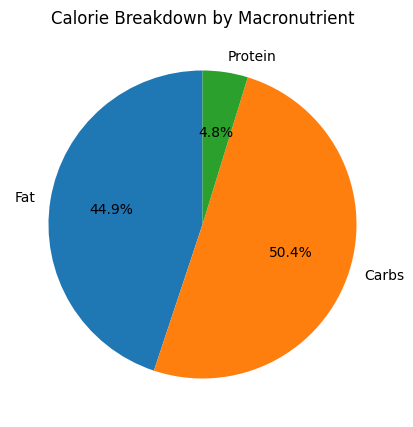

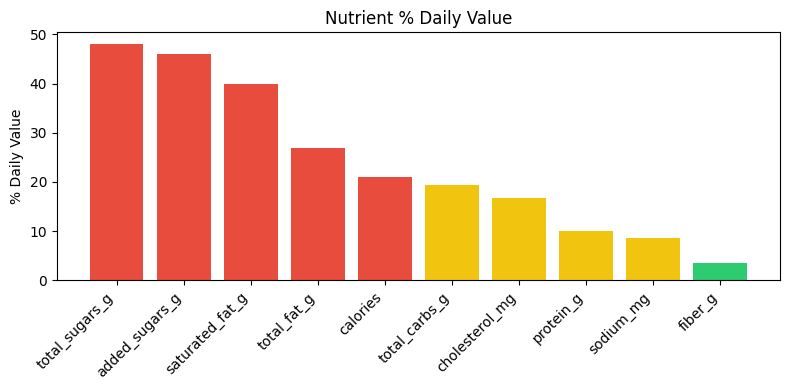

RESULT: saved to scan_report.pdf


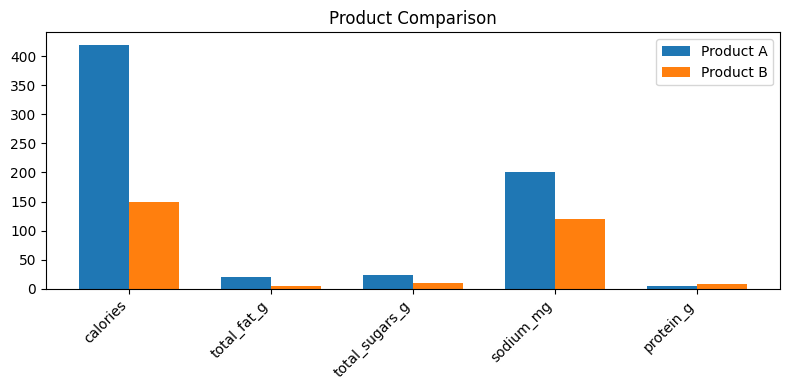

Saving label.jpg to label (1).jpg
RESULT: uploaded -> label (1).jpg
RESULT:
  quality: {'ok': True, 'issues': [], 'blur_score': np.float64(4974.0), 'brightness': np.float64(202.6)}
  ocr_confidence: 91.7
  nutrition: {'calories': 420, 'total_fat_g': 21.0, 'saturated_fat_g': 8.0, 'cholesterol_mg': 50.0, 'sodium_mg': 200.0, 'total_carbs_g': 53.0, 'fiber_g': 1.0, 'total_sugars_g': 24.0, 'added_sugars_g': 23.0, 'protein_g': 5.0, 'serving_size': '4oz (100g)'}
  vitamins: {'vitamin_d_mcg': 0.1, 'calcium_mg': 27.0, 'iron_mg': 1.8, 'potassium_mg': 90.0}
  daily_value_percent: {'calories': 21.0, 'total_fat_g': 26.9, 'saturated_fat_g': 40.0, 'cholesterol_mg': 16.7, 'sodium_mg': 8.7, 'total_carbs_g': 19.3, 'fiber_g': 3.6, 'total_sugars_g': 48.0, 'added_sugars_g': 46.0, 'protein_g': 10.0}
  barcodes: None
  certifications: []
  health_score: {'score': 59, 'label': 'Moderate'}
RESULT: 6 tests passed, 0 tests failed


In [52]:
!apt install tesseract-ocr -y
!pip install pytesseract opencv-python pillow requests python-dotenv

import pytesseract
from PIL import Image

def extract_text(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

result = extract_text("label.jpg")
print(result)

import re

def parse_nutrition(text):
    data = {}
    patterns = {
        'calories': r'calories\s*(\d+)',
        'total_fat_g': r'total fat\s*(\d+\.?\d*)\s*g',
        'saturated_fat_g': r'saturated fat\s*(\d+\.?\d*)\s*g',
        'cholesterol_mg': r'cholesterol\s*(\d+\.?\d*)\s*mg',
        'sodium_mg': r'sodium\s*(\d+\.?\d*)\s*mg',
        'total_carbs_g': r'total carboh[yi]d[nr]ate\s*(\d+\.?\d*)\s*g',
        'fiber_g': r'dietary fiber\s*(?:less than\s*)?(\d+\.?\d*)\s*g',
        'total_sugars_g': r'total sugars\s*(\d+\.?\d*)\s*g',
        'added_sugars_g': r'includes\s*(\d+\.?\d*)\s*g added sugars',
        'protein_g': r'protein\s*(\d+\.?\d*)\s*g',
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            value = match.group(1)
            data[key] = int(value) if key == 'calories' else float(value)

    serving_match = re.search(r'serving size\s*([^\n]+)', text, re.IGNORECASE)
    if serving_match:
        data['serving_size'] = serving_match.group(1).strip()
    return data

parsed = parse_nutrition(result)
print(parsed)

def generate_flags(data):
    flags = []
    if data.get('added_sugars_g', 0) >= 20:
        flags.append(f"⚠️ HIGH ADDED SUGAR: {data['added_sugars_g']}g per serving (WHO daily limit ~25g)")
    if data.get('sodium_mg', 0) >= 400:
        flags.append(f"⚠️ HIGH SODIUM: {data['sodium_mg']}mg per serving")
    if data.get('saturated_fat_g', 0) >= 5:
        flags.append(f"⚠️ HIGH SATURATED FAT: {data['saturated_fat_g']}g per serving")
    if data.get('total_carbs_g', 0) >= 30 and data.get('fiber_g', 0) < 3:
        flags.append(f"⚠️ LOW FIBER relative to carbs: only {data['fiber_g']}g fiber")
    if not flags:
        flags.append("✅ No major health flags detected")
    return flags

flags = generate_flags(parsed)
for f in flags:
    print(f)

import requests

def search_openfoodfacts(query):
    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {"search_terms": query, "json": 1, "page_size": 5}
    headers = {"User-Agent": "FoodLabelReader/1.0"}
    response = requests.get(url, params=params, headers=headers)
    if response.status_code != 200:
        return None
    try:
        return response.json()
    except:
        return None

result = search_openfoodfacts("nutella")
product = result['products'][0]
print("Product Name:", product.get('product_name'))
print("Brand:", product.get('brands'))

def get_clean_nutriments(product):
    n = product.get('nutriments', {})
    return {
        'calories_100g': n.get('energy-kcal_100g'), 'fat_100g': n.get('fat_100g'),
        'saturated_fat_100g': n.get('saturated-fat_100g'), 'carbs_100g': n.get('carbohydrates_100g'),
        'sugars_100g': n.get('sugars_100g'), 'sodium_100g': n.get('sodium_100g'), 'protein_100g': n.get('proteins_100g'),
    }

clean_data = get_clean_nutriments(product)
print(clean_data)

def compare_with_database(ocr_data, db_data):
    return {
        'ocr_sugar_g': ocr_data.get('total_sugars_g'),
        'db_sugar_per_100g': db_data.get('sugars_100g'),
        'ocr_sodium_mg': ocr_data.get('sodium_mg'),
        'db_sodium_per_100g': db_data.get('sodium_100g'),
    }

comparison = compare_with_database(parsed, clean_data)
print(comparison)

DAILY_VALUES = {
    'calories': 2000, 'total_fat_g': 78, 'saturated_fat_g': 20,
    'cholesterol_mg': 300, 'sodium_mg': 2300, 'total_carbs_g': 275,
    'fiber_g': 28, 'total_sugars_g': 50, 'added_sugars_g': 50, 'protein_g': 50,
}

def calculate_daily_value_percent(nutrient_data, daily_values=DAILY_VALUES):
    percentages = {}
    for nutrient, amount in nutrient_data.items():
        if nutrient in daily_values and amount is not None:
            percentages[nutrient] = round((amount / daily_values[nutrient]) * 100, 1)
    return percentages

dv_percent = calculate_daily_value_percent(parsed)
print(dv_percent)

def generate_readable_insights(dv_percent, parsed_data=None):
    insights = []
    for nutrient, pct in dv_percent.items():
        name = nutrient.replace('_g', '').replace('_mg', '').replace('_', ' ').title()
        if pct >= 40:
            insights.append(f"🔴 HIGH: {name} — {pct}% of your daily value in one serving")
        elif pct >= 20:
            insights.append(f"🟡 MODERATE: {name} — {pct}% of your daily value")
        elif pct <= 5:
            insights.append(f"🟢 LOW: {name} — only {pct}% of your daily value")
    return insights

insights = generate_readable_insights(dv_percent, parsed)
for i in insights:
    print(i)

sample_ingredients_text = "Ingredients: Wheat flour, Sugar, Palm oil, Milk solids, Cocoa powder, Soy lecithin, Salt, Artificial flavor, Sodium benzoate"

def parse_ingredients(text):
    text = text.replace("Ingredients:", "").strip()
    return [item.strip() for item in text.split(",")]

ingredients_list = parse_ingredients(sample_ingredients_text)
print(ingredients_list)

ALLERGEN_KEYWORDS = {
    'Milk/Dairy': ['milk', 'dairy', 'lactose', 'casein', 'whey', 'butter', 'cream', 'cheese'],
    'Soy': ['soy', 'soya', 'soybean'],
    'Wheat/Gluten': ['wheat', 'gluten', 'barley', 'rye', 'flour'],
    'Nuts': ['almond', 'cashew', 'walnut', 'peanut', 'pistachio', 'hazelnut'],
    'Egg': ['egg', 'albumin'],
    'Sesame': ['sesame', 'tahini'],
}

def detect_allergens(ingredients_list):
    detected = {}
    for ingredient in ingredients_list:
        ing_lower = ingredient.lower()
        for allergen, keywords in ALLERGEN_KEYWORDS.items():
            for keyword in keywords:
                if keyword in ing_lower:
                    detected.setdefault(allergen, [])
                    if ingredient not in detected[allergen]:
                        detected[allergen].append(ingredient)
                    break
    return detected

allergens_found = detect_allergens(ingredients_list)
print(allergens_found)

ADDITIVE_KEYWORDS = ['sodium benzoate', 'sodium nitrite', 'potassium sorbate', 'msg',
    'monosodium glutamate', 'artificial flavor', 'artificial color', 'aspartame',
    'high fructose corn syrup', 'bha', 'bht', 'sodium bisulfite', 'tartrazine', 'red 40', 'yellow 5', 'blue 1']

def detect_additives(ingredients_list):
    found = []
    for ingredient in ingredients_list:
        ing_lower = ingredient.lower()
        for additive in ADDITIVE_KEYWORDS:
            if additive in ing_lower:
                found.append(ingredient)
                break
    return found

additives_found = detect_additives(ingredients_list)
print(additives_found)

def get_nutriscore(product):
    grade = product.get('nutriscore_grade', 'unknown')
    meanings = {'a': 'Excellent', 'b': 'Good', 'c': 'Average', 'd': 'Poor', 'e': 'Bad', 'unknown': 'N/A'}
    return {'grade': grade.upper() if grade != 'unknown' else 'N/A', 'meaning': meanings.get(grade, 'Unknown')}

nutriscore = get_nutriscore(product)
print(nutriscore)

def get_nova_group(product):
    nova = product.get('nova_group', None)
    meanings = {1: 'Unprocessed/minimally processed', 2: 'Processed culinary ingredient', 3: 'Processed food', 4: 'Ultra-processed food'}
    return {'nova_group': nova, 'meaning': meanings.get(nova, 'Unknown')}

nova_info = get_nova_group(product)
print(nova_info)

def get_ecoscore(product):
    grade = product.get('ecoscore_grade', 'unknown')
    meanings = {'a': 'Very low impact', 'b': 'Low impact', 'c': 'Moderate impact', 'd': 'High impact', 'e': 'Very high impact', 'unknown': 'N/A'}
    return {'grade': grade.upper() if grade != 'unknown' else 'N/A', 'meaning': meanings.get(grade, 'Unknown')}

ecoscore = get_ecoscore(product)
print(ecoscore)

user_profile = {
    'is_diabetic': True,
    'is_hypertensive': False,
    'allergies': ['soy'],
    'goal': 'weight_loss'
}

def personalized_flags(dv_percent, allergens_found, user_profile):
    flags = []
    if user_profile['is_diabetic'] and dv_percent.get('added_sugars_g', 0) >= 20:
        flags.append(f"🔴 DIABETIC ALERT: {dv_percent['added_sugars_g']}% of daily sugar limit")
    if user_profile['is_hypertensive'] and dv_percent.get('sodium_mg', 0) >= 20:
        flags.append(f"🔴 HYPERTENSION ALERT: {dv_percent['sodium_mg']}% of daily sodium limit")
    for allergy in user_profile['allergies']:
        for allergen_type in allergens_found:
            if allergy.lower() in allergen_type.lower():
                flags.append(f"🚨 ALLERGY WARNING: Contains {allergen_type} — {allergens_found[allergen_type]}")
    if user_profile['goal'] == 'weight_loss' and dv_percent.get('calories', 0) >= 25:
        flags.append(f"⚠️ WEIGHT LOSS NOTE: {dv_percent['calories']}% of daily calories in one serving")
    return flags

personal_flags = personalized_flags(dv_percent, allergens_found, user_profile)
for f in personal_flags:
    print(f)

import datetime
scan_history = []

def log_scan(product_name, parsed_data, dv_percent):
    entry = {'product': product_name, 'timestamp': str(datetime.datetime.now()),
              'nutrition': parsed_data, 'daily_value_percent': dv_percent}
    scan_history.append(entry)
    return entry

log_scan("Test Product", parsed, dv_percent)
print(scan_history)

def calculate_daily_totals(history):
    totals = {}
    for scan in history:
        for nutrient, value in scan['nutrition'].items():
            if isinstance(value, (int, float)):
                totals[nutrient] = totals.get(nutrient, 0) + value
    return totals

daily_totals = calculate_daily_totals(scan_history)
print("RESULT:", daily_totals)

VEGAN_CONFLICT_KEYWORDS = ['milk', 'whey', 'casein', 'egg', 'honey', 'gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork']
VEGETARIAN_CONFLICT_KEYWORDS = ['gelatin', 'lard', 'meat', 'fish', 'chicken', 'beef', 'pork', 'rennet']

def check_diet_compatibility(ingredients_list):
    text = " ".join(ingredients_list).lower()
    vegan_conflicts = [kw for kw in VEGAN_CONFLICT_KEYWORDS if kw in text]
    veg_conflicts = [kw for kw in VEGETARIAN_CONFLICT_KEYWORDS if kw in text]
    return {
        'vegan_friendly': len(vegan_conflicts) == 0, 'vegan_conflicts': vegan_conflicts,
        'vegetarian_friendly': len(veg_conflicts) == 0, 'vegetarian_conflicts': veg_conflicts
    }

diet_check = check_diet_compatibility(ingredients_list)
print(diet_check)

def estimate_glycemic_load_risk(parsed_data):
    carbs = parsed_data.get('total_carbs_g', 0)
    fiber = parsed_data.get('fiber_g', 0)
    sugar = parsed_data.get('total_sugars_g', 0)
    net_carbs = carbs - fiber
    if sugar >= 15 and fiber < 3:
        risk = "HIGH — likely to spike blood sugar quickly"
    elif sugar >= 8 or net_carbs >= 20:
        risk = "MODERATE"
    else:
        risk = "LOW"
    return {'net_carbs_g': round(net_carbs, 1), 'blood_sugar_spike_risk': risk}

glycemic_info = estimate_glycemic_load_risk(parsed)
print(glycemic_info)

ARTIFICIAL_SWEETENERS = ['aspartame', 'sucralose', 'saccharin', 'acesulfame', 'stevia', 'xylitol', 'sorbitol', 'erythritol']

def detect_sweeteners(ingredients_list):
    text = " ".join(ingredients_list).lower()
    found = [sw for sw in ARTIFICIAL_SWEETENERS if sw in text]
    return found if found else "No artificial sweeteners detected"

sweeteners = detect_sweeteners(ingredients_list)
print(sweeteners)

def find_healthier_alternative(category_query, current_nutriscore):
    result = search_openfoodfacts(category_query)
    if not result:
        return "API error"
    grade_order = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
    current_rank = grade_order.get(current_nutriscore.lower(), 5)
    alternatives = []
    for p in result.get('products', []):
        grade = p.get('nutriscore_grade', '').lower()
        if grade and grade_order.get(grade, 5) < current_rank:
            alternatives.append({'name': p.get('product_name'), 'grade': grade.upper()})
    return alternatives[:5] if alternatives else "No healthier alternative found"

alternatives = find_healthier_alternative("chocolate spread", nutriscore['grade'])
print(alternatives)

def calculate_portion(parsed_data, num_servings):
    scaled = {}
    for key, value in parsed_data.items():
        scaled[key] = round(value * num_servings, 1) if isinstance(value, (int, float)) else value
    return scaled

portioned = calculate_portion(parsed, 2)
print(portioned)

import json

def export_report(report_data, filename="scan_report.json"):
    with open(filename, "w") as f:
        json.dump(report_data, f, indent=2)
    print(f"Report saved as {filename}")

full_report_data = {
    'nutrition': parsed, 'daily_value_percent': dv_percent, 'nutriscore': nutriscore,
    'ecoscore': ecoscore, 'allergens': allergens_found, 'additives': additives_found,
    'diet_compatibility': diet_check, 'glycemic_risk': glycemic_info, 'sweeteners': sweeteners
}
export_report(full_report_data)

def get_product_by_barcode(barcode):
    url = f"https://world.openfoodfacts.org/api/v2/product/{barcode}.json"
    headers = {"User-Agent": "FoodLabelReader/1.0"}
    response = requests.get(url, headers=headers)
    try:
        data = response.json()
        return data['product'] if data.get('status') == 1 else None
    except:
        return None

NON_HALAL_KOSHER_KEYWORDS = ['pork', 'lard', 'gelatin', 'alcohol', 'wine', 'rum', 'bacon', 'ham']

def check_halal_kosher(ingredients_list):
    text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in NON_HALAL_KOSHER_KEYWORDS if kw in text]
    return {'halal_kosher_safe': len(conflicts) == 0, 'conflicts': conflicts}

halal_kosher = check_halal_kosher(ingredients_list)
print("RESULT:", halal_kosher)

def compare_two_products(product1_data, product2_data):
    comparison = {}
    for key in product1_data:
        if key in product2_data and isinstance(product1_data[key], (int, float)):
            comparison[key] = {
                'product_1': product1_data[key],
                'product_2': product2_data[key],
                'lower_is': 'product_1' if product1_data[key] < product2_data[key] else 'product_2'
            }
    return comparison

comparison_result = compare_two_products(parsed, clean_data)
print("RESULT:", comparison_result)

def estimate_moisture_content(parsed_data):
    known = sum([parsed_data.get('total_fat_g', 0), parsed_data.get('total_carbs_g', 0), parsed_data.get('protein_g', 0)])
    return round(100 - known, 1) if known < 100 else 0

moisture = estimate_moisture_content(parsed)
print("RESULT:", moisture)

def extract_expiry_info(text):
    patterns = [
        r'(?:best before|exp(?:iry)?|use by)[:\s]*(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})',
        r'(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4})'
    ]
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group(1)
    return "Not found"

sample_text_with_date = "Best before: 12/05/2026"
expiry = extract_expiry_info(sample_text_with_date)
print("RESULT:", expiry)

api_cache = {}

def search_openfoodfacts_cached(query):
    if query in api_cache:
        return api_cache[query]
    result = search_openfoodfacts(query)
    if result:
        api_cache[query] = result
    return result

cached_result = search_openfoodfacts_cached("nutella")
if cached_result:
    print("RESULT:", cached_result['products'][0]['product_name'])
else:
    print("Request failed, try again")

# ============================================
# COMPLETE PIPELINE (redefines everything cleanly, then runs end-to-end)
# ============================================

import cv2

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    contrast = clahe.apply(gray)
    _, thresh = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cv2.imwrite("preprocessed.jpg", thresh)
    return "preprocessed.jpg"

processed_path = preprocess_image("label.jpg")
text_from_processed = extract_text(processed_path)
print(text_from_processed)

text = extract_text("label.jpg")
parsed = parse_nutrition(text)
dv_percent = calculate_daily_value_percent(parsed)
insights = generate_readable_insights(dv_percent)
for i in insights:
    print(i)

daily_totals = calculate_daily_totals(scan_history)
print("RESULT:", daily_totals)

import os
print("File exists:", os.path.exists("scan_report.json"))

barcode_test = get_product_by_barcode("YOUR_BARCODE_NUMBER_HERE")
print(barcode_test)

print("scan_history:", scan_history)
print("length:", len(scan_history))

def parse_vitamins_minerals(text):
    data = {}
    patterns = {
        'vitamin_d_mcg': r'vitamin d\s*(\d+\.?\d*)\s*mcg',
        'calcium_mg': r'calcium\s*(\d+\.?\d*)\s*mg',
        'iron_mg': r'iron\s*(\d+\.?\d*)\s*mg',
        'potassium_mg': r'potassium\s*(\d+\.?\d*)\s*mg',
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            data[key] = float(match.group(1))
    return data

vitamins = parse_vitamins_minerals(text)
print("RESULT:", vitamins)

VITAMIN_DAILY_VALUES = {'vitamin_d_mcg': 20, 'calcium_mg': 1300, 'iron_mg': 18, 'potassium_mg': 4700}

def calculate_vitamin_dv_percent(vitamin_data):
    percentages = {}
    for nutrient, amount in vitamin_data.items():
        if nutrient in VITAMIN_DAILY_VALUES:
            percentages[nutrient] = round((amount / VITAMIN_DAILY_VALUES[nutrient]) * 100, 1)
    return percentages

vitamin_dv = calculate_vitamin_dv_percent(vitamins)
print("RESULT:", vitamin_dv)

def safe_extract_text(image_path):
    try:
        img = Image.open(image_path)
        text = pytesseract.image_to_string(img)
        if not text.strip():
            return None, "No text detected — image may be too blurry or dark"
        return text, None
    except FileNotFoundError:
        return None, f"Image not found: {image_path}"
    except Exception as e:
        return None, f"OCR failed: {str(e)}"

def safe_parse_nutrition(text):
    if not text:
        return {}
    return parse_nutrition(text)

test_text, error = safe_extract_text("nonexistent.jpg")
print("RESULT:", test_text, "| ERROR:", error)

test_text2, error2 = safe_extract_text("label.jpg")
print("RESULT:", "Success" if test_text2 else error2)

def convert_to_grams(value, unit):
    unit = unit.lower()
    conversions = {'g': 1, 'kg': 1000, 'mg': 0.001, 'oz': 28.35, 'lb': 453.6}
    return round(value * conversions.get(unit, 1), 2)

converted = convert_to_grams(4, 'oz')
print("RESULT:", converted, "grams")

import glob

def batch_process_images(folder_path="*.jpg"):
    results = []
    image_files = glob.glob(folder_path)
    for img_path in image_files:
        text, error = safe_extract_text(img_path)
        if text:
            parsed_data = parse_nutrition(text)
            results.append({'image': img_path, 'data': parsed_data})
        else:
            results.append({'image': img_path, 'error': error})
    return results

batch_results = batch_process_images("*.jpg")
print("RESULT:", batch_results)

def run_tests():
    tests_passed = 0
    tests_failed = 0
    result = detect_allergens([])
    assert result == {}, "Empty ingredients should return empty dict"
    tests_passed += 1
    result = calculate_daily_value_percent({})
    assert result == {}, "Empty nutrition data should return empty dict"
    tests_passed += 1
    result = detect_allergens(["Milk powder"])
    assert 'Milk/Dairy' in result, "Should detect milk allergen"
    tests_passed += 1
    result = check_diet_compatibility(["Honey", "Water"])
    assert result['vegan_friendly'] == False, "Honey should trigger vegan conflict"
    tests_passed += 1
    print(f"RESULT: {tests_passed} tests passed, {tests_failed} tests failed")

run_tests()

# ============================================================
# PART 2 — MISSING FEATURES
# ============================================================

import sqlite3, time
import matplotlib.pyplot as plt
import numpy as np

!apt-get update -qq
!apt-get install -y libzbar0 -qq
!ldconfig
!pip install pyzbar reportlab langdetect -q

def check_image_quality(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return {'ok': False, 'reason': 'Could not read image'}
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()
    issues = []
    if blur_score < 100:
        issues.append(f'Image looks blurry (sharpness score: {blur_score:.1f}, want > 100)')
    if brightness < 60:
        issues.append(f'Image looks too dark (brightness: {brightness:.1f}/255)')
    elif brightness > 220:
        issues.append(f'Image looks overexposed/glare (brightness: {brightness:.1f}/255)')
    return {'ok': len(issues) == 0, 'issues': issues, 'blur_score': round(blur_score, 1), 'brightness': round(brightness, 1)}

quality = check_image_quality("label.jpg")
print("RESULT:", quality)

def deskew_image(image_path, output_path="deskewed.jpg"):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(thresh > 0))
    if len(coords) == 0:
        return image_path
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    cv2.imwrite(output_path, rotated)
    return output_path

deskewed_path = deskew_image("label.jpg")
print("RESULT: saved to", deskewed_path)

def extract_text_with_confidence(image_path):
    img = Image.open(image_path)
    data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
    confidences = [int(c) for c in data['conf'] if c != '-1' and int(c) >= 0]
    avg_confidence = round(sum(confidences) / len(confidences), 1) if confidences else 0
    low_conf_words = [data['text'][i] for i, c in enumerate(data['conf'])
                       if c != '-1' and 0 <= int(c) < 50 and data['text'][i].strip()]
    text = pytesseract.image_to_string(img)
    return {'text': text, 'avg_confidence': avg_confidence, 'reliable': avg_confidence >= 60, 'low_confidence_words': low_conf_words}

ocr_result = extract_text_with_confidence("label.jpg")
print("RESULT: avg_confidence =", ocr_result['avg_confidence'], "| reliable =", ocr_result['reliable'])

from pyzbar.pyzbar import decode as zbar_decode

def scan_barcode_from_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, "Could not read image"
    barcodes = zbar_decode(img)
    if not barcodes:
        return None, "No barcode detected in image"
    results = [{'data': b.data.decode('utf-8'), 'type': b.type} for b in barcodes]
    return results, None

barcodes_found, err = scan_barcode_from_image("label.jpg")
print("RESULT:", barcodes_found if barcodes_found else err)

!apt-get install -y tesseract-ocr-hin -q

def extract_text_multilang(image_path, langs="eng+hin"):
    img = Image.open(image_path)
    try:
        text = pytesseract.image_to_string(img, lang=langs)
    except pytesseract.TesseractError:
        text = pytesseract.image_to_string(img, lang="eng")
    return text

multilang_text = extract_text_multilang("label.jpg")
print("RESULT:", multilang_text[:300])

def parse_nutrition_extended(text):
    data = parse_nutrition(text)
    extra_patterns = {
        'trans_fat_g': r'trans fat\s*(\d+\.?\d*)\s*g',
        'polyunsaturated_fat_g': r'polyunsaturated fat\s*(\d+\.?\d*)\s*g',
        'monounsaturated_fat_g': r'monounsaturated fat\s*(\d+\.?\d*)\s*g',
    }
    for key, pattern in extra_patterns.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            data[key] = float(match.group(1))
    return data

extended_nutrition = parse_nutrition_extended(text_from_processed)
print("RESULT:", extended_nutrition)

EXTRA_VITAMIN_PATTERNS = {
    'vitamin_a_mcg': r'vitamin a\s*(\d+\.?\d*)\s*mcg',
    'vitamin_c_mg': r'vitamin c\s*(\d+\.?\d*)\s*mg',
    'vitamin_b12_mcg': r'vitamin b12\s*(\d+\.?\d*)\s*mcg',
    'folate_mcg': r'folate\s*(\d+\.?\d*)\s*mcg',
    'magnesium_mg': r'magnesium\s*(\d+\.?\d*)\s*mg',
    'zinc_mg': r'zinc\s*(\d+\.?\d*)\s*mg',
}

def parse_vitamins_extended(text):
    data = parse_vitamins_minerals(text)
    for key, pattern in EXTRA_VITAMIN_PATTERNS.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            data[key] = float(match.group(1))
    return data

extended_vitamins = parse_vitamins_extended(text_from_processed)
print("RESULT:", extended_vitamins)

ALLERGEN_KEYWORDS_EXTENDED = dict(ALLERGEN_KEYWORDS)
ALLERGEN_KEYWORDS_EXTENDED.update({
    'Sulphites': ['sulphite', 'sulfite', 'so2'],
    'Mustard': ['mustard'],
    'Celery': ['celery', 'celeriac'],
    'Lupin': ['lupin', 'lupine'],
    'Molluscs': ['mussel', 'oyster', 'squid', 'snail', 'clam', 'scallop'],
    'Crustaceans': ['shrimp', 'prawn', 'crab', 'lobster'],
    'Fish': ['fish', 'anchovy', 'cod', 'salmon', 'tuna'],
})

def _detect(ingredients_list):
    detected = {}
    for ingredient in ingredients_list:
        ingredient_lower = ingredient.lower()
        for allergen, keywords in ALLERGEN_KEYWORDS_EXTENDED.items():
            for keyword in keywords:
                if keyword in ingredient_lower:
                    detected.setdefault(allergen, []).append(ingredient)
                    break
    return detected

def detect_cross_contamination_warning(raw_text):
    pattern = r'(may contain( traces of)?|processed in a facility that (also )?(processes|handles))\s*([^.\n]+)'
    match = re.search(pattern, raw_text, re.IGNORECASE)
    return match.group(0).strip() if match else None

allergens_extended = _detect(ingredients_list)
cross_contam = detect_cross_contamination_warning(text_from_processed)
print("RESULT allergens:", allergens_extended)
print("RESULT cross-contamination warning:", cross_contam)

HIGH_CARB_KEYWORDS = ['sugar', 'corn syrup', 'wheat flour', 'rice', 'maltodextrin', 'dextrose']
PALEO_CONFLICT_KEYWORDS = ['sugar', 'wheat', 'corn', 'dairy', 'milk', 'legume', 'soy', 'peanut', 'artificial']
FODMAP_CONFLICT_KEYWORDS = ['garlic', 'onion', 'honey', 'high fructose corn syrup', 'wheat', 'inulin', 'sorbitol', 'xylitol']

def check_keto_compatibility(parsed_data, ingredients_list):
    carbs = parsed_data.get('total_carbs_g', 0)
    fiber = parsed_data.get('fiber_g', 0)
    net_carbs = max(carbs - fiber, 0)
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in HIGH_CARB_KEYWORDS if kw in ingredients_text]
    return {'keto_friendly': net_carbs <= 10 and len(conflicts) == 0, 'net_carbs_g': net_carbs, 'conflicts': conflicts}

def check_paleo_compatibility(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in PALEO_CONFLICT_KEYWORDS if kw in ingredients_text]
    return {'paleo_friendly': len(conflicts) == 0, 'conflicts': conflicts}

def check_fodmap_compatibility(ingredients_list):
    ingredients_text = " ".join(ingredients_list).lower()
    conflicts = [kw for kw in FODMAP_CONFLICT_KEYWORDS if kw in ingredients_text]
    return {'low_fodmap': len(conflicts) == 0, 'conflicts': conflicts}

print("RESULT keto:", check_keto_compatibility(parsed, ingredients_list))
print("RESULT paleo:", check_paleo_compatibility(ingredients_list))
print("RESULT fodmap:", check_fodmap_compatibility(ingredients_list))

CERTIFICATION_PATTERNS = {
    'Halal Certified': r'halal\s*certifi',
    'Kosher Certified': r'kosher\s*certifi',
    'USDA Organic': r'usda\s*organic|certified organic',
    'Gluten-Free Certified': r'certified gluten[- ]free|gluten[- ]free certified',
    'Non-GMO Verified': r'non[- ]gmo',
    'Fair Trade': r'fair\s*trade',
}

def detect_certifications(raw_text):
    found = []
    for cert, pattern in CERTIFICATION_PATTERNS.items():
        if re.search(pattern, raw_text, re.IGNORECASE):
            found.append(cert)
    return found

certifications = detect_certifications(text_from_processed)
print("RESULT:", certifications if certifications else "No certification text detected on label")

def calculate_health_score(dv_percent, nova_group, nutriscore_grade, additives_found, allergens_found):
    score = 100
    for key, weight in [('saturated_fat_g', 0.3), ('total_sugars_g', 0.3), ('sodium_mg', 0.2)]:
        pct = dv_percent.get(key, 0)
        if pct > 20:
            score -= (pct - 20) * weight
    if nova_group == 4:
        score -= 15
    elif nova_group == 3:
        score -= 7
    grade_penalty = {'a': 0, 'b': 5, 'c': 12, 'd': 20, 'e': 28}
    score -= grade_penalty.get(str(nutriscore_grade).lower(), 10)
    score -= min(len(additives_found) * 3, 15)
    score = max(0, min(100, round(score)))
    if score >= 80:
        label = 'Excellent'
    elif score >= 60:
        label = 'Good'
    elif score >= 40:
        label = 'Moderate'
    else:
        label = 'Poor'
    return {'score': score, 'label': label}

health_score = calculate_health_score(
    dv_percent=dv_percent, nova_group=4, nutriscore_grade='d',
    additives_found=additives_found, allergens_found=allergens_extended
)
print("RESULT:", health_score)

def extended_personalized_flags(dv_percent, parsed_data, user_profile):
    flags = []
    if user_profile.get('is_kidney_patient'):
        if dv_percent.get('potassium_mg', 0) >= 15:
            flags.append(f"🔴 KIDNEY ALERT: {dv_percent.get('potassium_mg')}% of daily potassium limit")
        if dv_percent.get('sodium_mg', 0) >= 15:
            flags.append(f"🔴 KIDNEY ALERT: {dv_percent.get('sodium_mg')}% of daily sodium limit")
    if user_profile.get('is_pregnant'):
        if 'unpasteurized' in str(parsed_data).lower():
            flags.append("🔴 PREGNANCY ALERT: possible unpasteurized ingredient")
    if user_profile.get('goal') == 'weight_loss':
        calories = parsed_data.get('calories', 0)
        daily_budget = user_profile.get('daily_calorie_budget', 2000)
        pct_of_budget = round(calories / daily_budget * 100, 1) if daily_budget else 0
        flags.append(f"ℹ️ This item uses {pct_of_budget}% of your daily calorie budget")
    if user_profile.get('goal') == 'muscle_gain':
        protein = parsed_data.get('protein_g', 0)
        if protein < 10:
            flags.append(f"🟡 LOW PROTEIN: only {protein}g — consider a higher-protein option")
    return flags

extended_profile = {'is_kidney_patient': False, 'is_pregnant': False, 'goal': 'weight_loss', 'daily_calorie_budget': 1800}
print("RESULT:", extended_personalized_flags(dv_percent, parsed, extended_profile))

import pandas as pd

def analyze_scan_trends(scan_history):
    if not scan_history:
        return "No scan history yet"
    df = pd.DataFrame(scan_history)
    if 'date' not in df.columns:
        df['date'] = datetime.date.today().isoformat()
    numeric_cols = [c for c in ['calories', 'total_sugars_g', 'sodium_mg'] if c in df.columns]
    if not numeric_cols:
        return "No numeric nutrition fields in scan history yet"
    return df.groupby('date')[numeric_cols].sum().reset_index()

trend_table = analyze_scan_trends(scan_history)
print("RESULT:")
print(trend_table)

DB_PATH = "food_scans.db"

def init_db(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.execute('''CREATE TABLE IF NOT EXISTS scans (
        id INTEGER PRIMARY KEY AUTOINCREMENT, product_name TEXT, scan_date TEXT,
        nutrition_json TEXT, health_score INTEGER)''')
    conn.commit()
    return conn

def save_scan_to_db(product_name, nutrition_data, health_score_val, conn=None):
    close_after = conn is None
    conn = conn or init_db()
    conn.execute(
        "INSERT INTO scans (product_name, scan_date, nutrition_json, health_score) VALUES (?, ?, ?, ?)",
        (product_name, datetime.date.today().isoformat(), json.dumps(nutrition_data), health_score_val)
    )
    conn.commit()
    if close_after:
        conn.close()

def load_all_scans(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    rows = conn.execute("SELECT product_name, scan_date, nutrition_json, health_score FROM scans").fetchall()
    conn.close()
    return [{'product_name': r[0], 'date': r[1], 'nutrition': json.loads(r[2]), 'health_score': r[3]} for r in rows]

conn = init_db()
save_scan_to_db("Test Product", parsed, health_score['score'], conn)
print("RESULT: saved. All scans so far ->")
print(load_all_scans())

LOCAL_NUTRITION_DB = {
    'banana': {'calories': 89, 'total_carbs_g': 23, 'fiber_g': 2.6, 'protein_g': 1.1, 'total_sugars_g': 12},
    'white rice (cooked)': {'calories': 130, 'total_carbs_g': 28, 'fiber_g': 0.4, 'protein_g': 2.7, 'total_sugars_g': 0.1},
    'whole milk': {'calories': 61, 'total_fat_g': 3.3, 'protein_g': 3.2, 'total_sugars_g': 5, 'calcium_mg': 113},
}

def lookup_with_fallback(query, api_lookup_fn=search_openfoodfacts):
    try:
        result = api_lookup_fn(query)
        if result:
            return result, 'api'
    except Exception:
        pass
    key = query.strip().lower()
    if key in LOCAL_NUTRITION_DB:
        return LOCAL_NUTRITION_DB[key], 'local_fallback'
    return None, 'not_found'

result_fb, source_fb = lookup_with_fallback("banana")
print("RESULT:", result_fb, "| source:", source_fb)

def api_get_with_retry(url, params=None, headers=None, max_retries=3, timeout=5, min_interval=1.0):
    if not hasattr(api_get_with_retry, '_last_call'):
        api_get_with_retry._last_call = 0
    elapsed = time.time() - api_get_with_retry._last_call
    if elapsed < min_interval:
        time.sleep(min_interval - elapsed)
    last_error = None
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=timeout)
            api_get_with_retry._last_call = time.time()
            if response.status_code == 200:
                return response, None
            last_error = f"HTTP {response.status_code}"
        except requests.exceptions.Timeout:
            last_error = "Timeout"
        except requests.exceptions.RequestException as e:
            last_error = str(e)
        time.sleep(2 ** attempt)
    return None, last_error

resp, err = api_get_with_retry(
    "https://world.openfoodfacts.org/cgi/search.pl",
    params={"search_terms": "banana", "json": 1, "page_size": 1},
    headers={"User-Agent": "FoodLabelReader/1.0"}
)
print("RESULT:", "success" if resp else f"failed after retries: {err}")

def plot_macro_breakdown(parsed_data):
    macros = {
        'Fat': parsed_data.get('total_fat_g', 0) * 9,
        'Carbs': parsed_data.get('total_carbs_g', 0) * 4,
        'Protein': parsed_data.get('protein_g', 0) * 4,
    }
    macros = {k: v for k, v in macros.items() if v > 0}
    if not macros:
        print("No macro data to plot")
        return
    plt.figure(figsize=(5, 5))
    plt.pie(macros.values(), labels=macros.keys(), autopct='%1.1f%%', startangle=90)
    plt.title('Calorie Breakdown by Macronutrient')
    plt.show()

def plot_dv_bar_chart(dv_percent):
    if not dv_percent:
        print("No %DV data to plot")
        return
    items = sorted(dv_percent.items(), key=lambda x: x[1], reverse=True)
    labels, values = zip(*items)
    plt.figure(figsize=(8, 4))
    colors = ['#e74c3c' if v >= 20 else ('#f1c40f' if v >= 5 else '#2ecc71') for v in values]
    plt.bar(labels, values, color=colors)
    plt.ylabel('% Daily Value')
    plt.title('Nutrient % Daily Value')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_macro_breakdown(parsed)
plot_dv_bar_chart(dv_percent)

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas

def export_report_pdf(report_text, filename="scan_report.pdf"):
    c = canvas.Canvas(filename, pagesize=letter)
    width, height = letter
    text_obj = c.beginText(40, height - 50)
    text_obj.setFont("Helvetica", 10)
    for line in report_text.split("\n"):
        text_obj.textLine(line)
        if text_obj.getY() < 40:
            c.drawText(text_obj)
            c.showPage()
            text_obj = c.beginText(40, height - 50)
            text_obj.setFont("Helvetica", 10)
    c.drawText(text_obj)
    c.save()
    return filename

sample_report_text = str(full_report_data)
pdf_path = export_report_pdf(sample_report_text)
print("RESULT: saved to", pdf_path)

def plot_product_comparison(product1_name, product1_data, product2_name, product2_data):
    keys = ['calories', 'total_fat_g', 'total_sugars_g', 'sodium_mg', 'protein_g']
    keys = [k for k in keys if k in product1_data or k in product2_data]
    vals1 = [product1_data.get(k, 0) for k in keys]
    vals2 = [product2_data.get(k, 0) for k in keys]
    x = np.arange(len(keys))
    width = 0.35
    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, vals1, width, label=product1_name)
    plt.bar(x + width/2, vals2, width, label=product2_name)
    plt.xticks(x, keys, rotation=45, ha='right')
    plt.legend()
    plt.title('Product Comparison')
    plt.tight_layout()
    plt.show()

plot_product_comparison("Product A", parsed, "Product B", {'calories': 150, 'total_fat_g': 5, 'total_sugars_g': 10, 'sodium_mg': 120, 'protein_g': 8})

try:
    from google.colab import files
    uploaded = files.upload()
    uploaded_image_path = list(uploaded.keys())[0]
    print("RESULT: uploaded ->", uploaded_image_path)
except ImportError:
    print("Not running on Colab — skipping upload widget.")
    uploaded_image_path = "label.jpg"

def main(image_path, user_profile=None, save_to_db=True):
    user_profile = user_profile or {'is_diabetic': False, 'is_hypertensive': False, 'allergies': [], 'goal': 'maintenance'}
    quality = check_image_quality(image_path)
    if not quality['ok']:
        print("⚠️ Image quality warning:", quality['issues'])
    working_path = deskew_image(image_path)
    ocr = extract_text_with_confidence(working_path)
    if not ocr['reliable']:
        print(f"⚠️ Low OCR confidence ({ocr['avg_confidence']}%) — results may be inaccurate")
    nutrition = parse_nutrition_extended(ocr['text'])
    vitamins_data = parse_vitamins_extended(ocr['text'])
    dv = calculate_daily_value_percent(nutrition) if nutrition else {}
    barcodes, _ = scan_barcode_from_image(image_path)
    certs = detect_certifications(ocr['text'])
    cross_contam_warning = detect_cross_contamination_warning(ocr['text'])
    score = calculate_health_score(dv, nova_group=4, nutriscore_grade='c', additives_found=[], allergens_found={})
    if save_to_db:
        save_scan_to_db(image_path, nutrition, score['score'])
    return {
        'quality': quality, 'ocr_confidence': ocr['avg_confidence'], 'nutrition': nutrition,
        'vitamins': vitamins_data, 'daily_value_percent': dv, 'barcodes': barcodes,
        'certifications': certs, 'cross_contamination_warning': cross_contam_warning, 'health_score': score,
    }

final_result = main("label.jpg", user_profile=extended_profile)
print("RESULT:")
for k, v in final_result.items():
    print(f"  {k}: {v}")

def run_extended_tests():
    passed, failed = 0, 0
    def check(condition, msg):
        nonlocal passed, failed
        if condition:
            passed += 1
        else:
            failed += 1
            print("FAILED:", msg)
    check(check_image_quality("nonexistent.jpg")['ok'] == False, "Missing image should fail quality check")
    check('trans_fat_g' in parse_nutrition_extended("Trans Fat 2g"), "Trans fat should be parsed")
    check(check_keto_compatibility({'total_carbs_g': 50, 'fiber_g': 2}, ["sugar"])['keto_friendly'] == False, "High-carb + sugar should fail keto check")
    check(check_paleo_compatibility(["water", "salt"])['paleo_friendly'] == True, "Water+salt should pass paleo")
    check(detect_certifications("USDA Organic certified product") == ['USDA Organic'], "Should detect USDA Organic text")
    check(0 <= calculate_health_score({}, 1, 'a', [], {})['score'] <= 100, "Health score should be within 0-100")
    print(f"RESULT: {passed} tests passed, {failed} tests failed")

run_extended_tests()